In [1]:
import os
# import popv
import scanpy as sc
import seaborn as sns
import anndata as ad
# import tangram as tg

In [2]:
st_data = sc.read_h5ad('skin_expansion_data/merged_skin_spatial.h5ad')

/data/leuven/337/vsc33740/miniforge3/envs/popv/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
st_data

AnnData object with n_obs × n_vars = 118250 × 474
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'Slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'n_counts', 'immune_pool', 'condition', 'sample'
    obsm: 'spatial'
    layers: 'log1p_norm', 'rawcounts'

In [10]:
import numpy as np

# Calculate per-cell total counts (from the count matrix)
if isinstance(st_data.layers['rawcounts'], np.ndarray):
    total_counts = st_data.layers['rawcounts'].sum(axis=1)
else:  # If it's a sparse matrix
    total_counts = np.array(st_data.layers['rawcounts'].sum(axis=1)).flatten()

print(f"Minimum total count per cell: {total_counts.min()}")
print(f"Number of cells with <30 counts: {(total_counts < 30).sum()}")


Minimum total count per cell: 5.0
Number of cells with <30 counts: 62214


In [10]:
scrna = sc.read_h5ad('project_helmsley/Helmsley/MARKUS_ASAP_sn_UZonly_cluster.h5ad')

In [8]:
temp = sc.read_h5ad('project_helmsley/Helmsley/Nathalie_merged_vizgen.h5ad')

In [9]:
temp

AnnData object with n_obs × n_vars = 1424982 × 296
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'slide', 'slide_region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'n_counts'
    uns: 'slide_region_colors'
    obsm: 'blank_genes', 'spatial'

In [2]:
from __future__ import annotations
import logging
import torch
import tangram as tg
import numpy as np
import pandas as pd

class Tangram_POPV:
    def __init__(self, cluster_label="celltype_deep", mode="clusters", density_prior="uniform", device="cuda:0"):
        """
        Class to perform Tangram-based integration of scRNA-seq data into spatial transcriptomics data.

        Parameters
        ----------
        cluster_label : str
            Label for clustering in scRNA-seq dataset.
        mode : str
            Mode for Tangram mapping ('cells' or 'clusters').
        density_prior : str
            Density prior for Tangram ('uniform' by default).
        device : str
            Device to use ('cuda:0' or 'cpu').
        """
        self.cluster_label = cluster_label
        self.mode = mode
        self.density_prior = density_prior
        self.device = device

    def compute_integration(self, adata):
        logging.info("Integrating data with Tangram")

        # Split data into query (spatial data) and reference (scRNA-seq data)
        query_data = adata[adata.obs["_dataset"] == "query"].copy()
        ref_data = adata[adata.obs["_dataset"] == "ref"].copy()

        # Ensure that genes in ref_data and query_data are aligned
        tg.pp_adatas(ref_data, query_data)

        # Tangram mapping: scRNA-seq (reference) to spatial data (query)
        ad_map = tg.map_cells_to_space(
            ref_data,
            query_data,
            mode=self.mode,
            cluster_label=self.cluster_label,
            density_prior=self.density_prior,
            device=self.device
        )

        # Project cell annotations from reference scRNA-seq to query spatial data
        tg.project_cell_annotations(ad_map, query_data, annotation=self.cluster_label)

        # Add Tangram cell-type annotations for the query data
        query_data.obs['popv_tangram_prediction'] = query_data.obsm['tangram_ct_pred'].idxmax(axis=1)

        # For reference cells, retain the original labels
        ref_data.obs['popv_tangram_prediction'] = ref_data.obs[self.cluster_label]

        # Merge Tangram results back into the combined `adata` object
        adata.obs.loc[query_data.obs.index, 'popv_tangram_prediction'] = query_data.obs['popv_tangram_prediction']
        adata.obs.loc[ref_data.obs.index, 'popv_tangram_prediction'] = ref_data.obs['popv_tangram_prediction']

        # Add 'popv_tangram_prediction' and 'popv_tangram_prediction_norm' to the list of prediction keys in `adata.uns`
        if 'prediction_keys' not in adata.uns:
            adata.uns['prediction_keys'] = []
        adata.uns['prediction_keys'].extend(['popv_tangram_prediction'])

        # Optionally, return the modified AnnData
        return adata

In [3]:
output_folder = "popv_output"
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [3]:
scrna_data = sc.read_h5ad('skin_expansion_data/adata_harmony_caroline_belgium.h5ad')
scrna_data.obs_names_make_unique()
scrna_data.obs['celltype_deep'].replace("keratinocytes_basal", "Keratinocytes", inplace=True)
scrna_data = scrna_data[scrna_data.obs['celltype_deep']!='Lower dermis Fibroblast 4']

# Load spatial transcriptomics data
st_data = sc.read_h5ad('skin_expansion_data/merged_skin_spatial_control_integrated.h5ad')
st_data.obs_names_make_unique()

In [4]:
import numpy as np

# Find the intersection of genes between the two datasets
common_genes = np.intersect1d(scrna_data.var_names, st_data.var_names)

# Subset both datasets to retain only common genes
scrna_data = scrna_data[:, common_genes]
st_data = st_data[:, common_genes]

print(f"Number of common genes retained: {len(common_genes)}")

Number of common genes retained: 474


In [5]:
from popv.preprocessing import Process_Query
from popv.annotation import annotate_data

# Assuming raw counts are stored in the 'rawcounts' layer
scrna_data_raw = scrna_data.layers['rawcounts']
st_data_raw = st_data.layers['rawcounts']

# Use raw counts for both datasets
scrna_data.X = scrna_data_raw.copy()
st_data.X = st_data_raw.copy()

# Subset scrna_data to control condition only
control_only = scrna_data.obs['condition'] == 'Control'
scrna_data = scrna_data[control_only, :]

# Add a column named 'celltype_deep' with 'unknown' as the value for all cells in st_data
# st_data.obs['celltype_deep'] = "unknown"

In [7]:
# With 30 counts we filter length=9476 cells 
# adapted source code so we filter only cells with 10 counts 
# Process the query data (spatial data) using Process_Query
processed_adata = Process_Query(
    st_data,  # Query data (spatial dataset)
    scrna_data,  # Reference data (scRNA-seq, control only)
    query_labels_key=None,  # No labels initially in query data
    query_batch_key='sample',  # No batch information in query data
    ref_labels_key='celltype_deep',  # Use 'celltype_deep' from scrna_data
    ref_batch_key='batch',  # 'batch' will serve as the batch key
    unknown_celltype_label=None,  # Label for unknown cell types
    save_path_trained_models="trained_models_path",  # Path to save trained models (optional)
    cl_obo_folder=False,  # No ontology folder required
    prediction_mode="retrain",  # Use 'inference' to avoid retraining models
    accelerator="cuda",  # Use 'cuda' if GPU is available, otherwise 'cpu'
    compute_embedding=True,
    hvg=None,# Use all genes as we already filtered by common genes
    n_samples_per_label=10000
).adata
processed_adata.uns["unknown_celltype_label"]='unknown'

Sampling 10000 per label
The following cells will be excluded from annotation because they have low expression:Index(['GTGTCCTAGCGTGTTT-1-2', 'TGATTTCAGGTCACCC-1-8', 'AAATGGATCTAGAGCT-1-8',
       'hoknlmha-1', 'holglpcb-1', 'hokjbhbd-1', 'hokhmjdb-1', 'hokeklec-1',
       'hojjdphm-1', 'hohkkiig-1',
       ...
       'gbbdfkjo-1', 'ddmkofke-1', 'ddmeiapb-1', 'ddmaiokg-1', 'jbeilpjj-1',
       'jbeipkfj-1', 'jbhnaggk-1', 'jbbhiffj-1', 'japimlgf-1', 'jclapmmg-1'],
      dtype='object', length=9476).


In [8]:
# Annotate the processed data
annotate_data(processed_adata,save_path="popv_output")

Saving celltypist results to adata.obs["popv_celltypist_prediction"]
🍳 Preparing data before training
✂️ 18 non-expressed genes are filtered out
🔬 Input data has 22181 cells and 456 genes
⚖️ Scaling input data
🏋️ Training data using logistic regression
✅ Model training done!
🔬 Input data has 85344 cells and 474 genes
🔗 Matching reference genes in the model
🧬 456 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!
Integrating data with bbknn


Saving knn on bbknn results to adata.obs["popv_knn_on_bbknn_prediction"]
Saving UMAP of bbknn results to adata.obs["X_bbknn_umap_popv"]
Integrating data with harmony


	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).


Saving knn on harmony results to adata.obs["popv_knn_on_harmony_prediction"]


	Completed 10 / 10 iteration(s).


...

Epoch 20/20: 100%|██████████| 20/20 [00:46<00:00,  2.32s/it, v_num=1, train_loss_step=127, train_loss_epoch=134]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [00:46<00:00,  2.32s/it, v_num=1, train_loss_step=127, train_loss_epoch=134]

Saving scanvi label prediction to adata.obs["popv_scanvi_prediction"]


Saving UMAP of scanvi results to adata.obs["X_scanvi_umap_popv"]
Computing support vector machine. Storing prediction in adata.obs["popv_svm_prediction"]
Using predictions ['popv_celltypist_prediction', 'popv_knn_on_bbknn_prediction', 'popv_knn_on_harmony_prediction', 'popv_knn_on_scanorama_prediction', 'popv_knn_on_scvi_prediction', 'popv_rf_prediction', 'popv_scanvi_prediction', 'popv_svm_prediction'] for PopV consensus
Predictions saved to popv_output/predictions.csv


In [9]:
processed_adata

AnnData object with n_obs × n_vars = 85344 × 474
    obs: 'scdbl_class', 'batch', 'condition', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'leiden_res_1.0', 'leiden_res_0.5', 'leiden_res_0.2', 'celltype', 'hash.ID', 'celltype_caro', 'celltype_deep', '_batch_annotation', '_labels_annotation', '_ref_subsample', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'cell_area', 'nucleus_area', 'region', 'Slide', 'n_counts', 'immune_pool', 'sample', 'leiden_igraph_res_1.0', 'leiden_igraph_res_2.0', '_dataset', 'popv_celltypist_prediction', 'popv_celltypist_prediction_probabilities'

In [10]:
# Initialize Tangram_POPV class
tangram_popv = Tangram_POPV(
    cluster_label="celltype_deep",
    mode="cells",
    density_prior="uniform",
    device="cuda:0")

# Perform Tangram integration and add results to `processed_adata`
processed_adata = tangram_popv.compute_integration(processed_adata)

Integrating data with Tangram
456 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
456 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
Allocate tensors for mapping.
Begin training with 456 genes and uniform density_prior in cells mode...
Printing scores every 100 epochs.


Score: 0.219, KL reg: 0.000
Score: 0.703, KL reg: 0.013
Score: 0.739, KL reg: 0.007
Score: 0.750, KL reg: 0.006
Score: 0.756, KL reg: 0.005
Score: 0.759, KL reg: 0.005
Score: 0.761, KL reg: 0.005
Score: 0.762, KL reg: 0.005
Score: 0.763, KL reg: 0.005
Score: 0.764, KL reg: 0.005


Saving results..
spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


In [ ]:
dotr_annot = pd.read_csv('DOT_celltyping_results_with_scores.csv', index_col=0)

# Split processed_adata into reference and query data based on `_dataset` information
ref_indices = processed_adata.obs[processed_adata.obs["_dataset"] == "ref"].index
query_indices = processed_adata.obs[processed_adata.obs["_dataset"] == "query"].index

# Ensure that the indices match in both query data and dotr_annot
common_indices = query_indices.intersection(dotr_annot.index)

# Add 'popv_dotR_prediction' column to processed_adata
# For reference cells, use 'celltype_deep' annotation
processed_adata.obs['popv_dotR_prediction'] = processed_adata.obs['celltype_deep']
# For query cells, use DOT R annotation (or 'unknown' if no data available)
# processed_adata.obs.loc[query_indices, 'popv_dotR_prediction'] = "unknown"
processed_adata.obs.loc[common_indices, 'popv_dotR_prediction'] = dotr_annot.loc[common_indices, 'predicted_cell_type']

# Add 'popv_dotR_prediction_score' column to processed_adata
# For reference cells, use NaN since there is no prediction score
processed_adata.obs['popv_dotR_prediction_score'] = float('nan')
# For query cells, use DOT R prediction scores
processed_adata.obs.loc[common_indices, 'popv_dotR_prediction_score'] = dotr_annot.loc[common_indices, 'prediction_score']

# Add the new prediction keys to processed_adata.uns['prediction_keys']
if 'prediction_keys' not in processed_adata.uns:
    processed_adata.uns['prediction_keys'] = []

processed_adata.uns['prediction_keys'].append('popv_dotR_prediction')

print("DOT R annotations have been added to processed_adata.")

DOT R annotations have been added to processed_adata.


In [ ]:
popv.annotation.compute_consensus(processed_adata,prediction_keys=processed_adata.uns["prediction_keys"])

In [16]:
processed_adata.write(f'skin_expansion_data/query_and_reference_popv.h5ad')

In [18]:
processed_adata.obsm["X_umap"] = processed_adata.obsm["X_scanvi_umap_popv"]

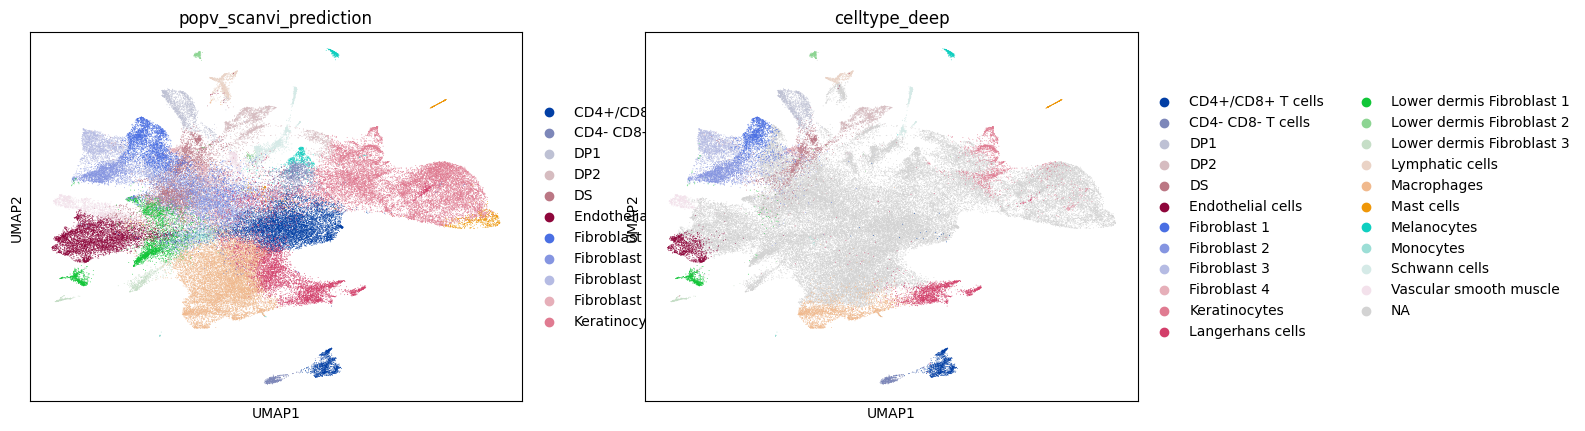

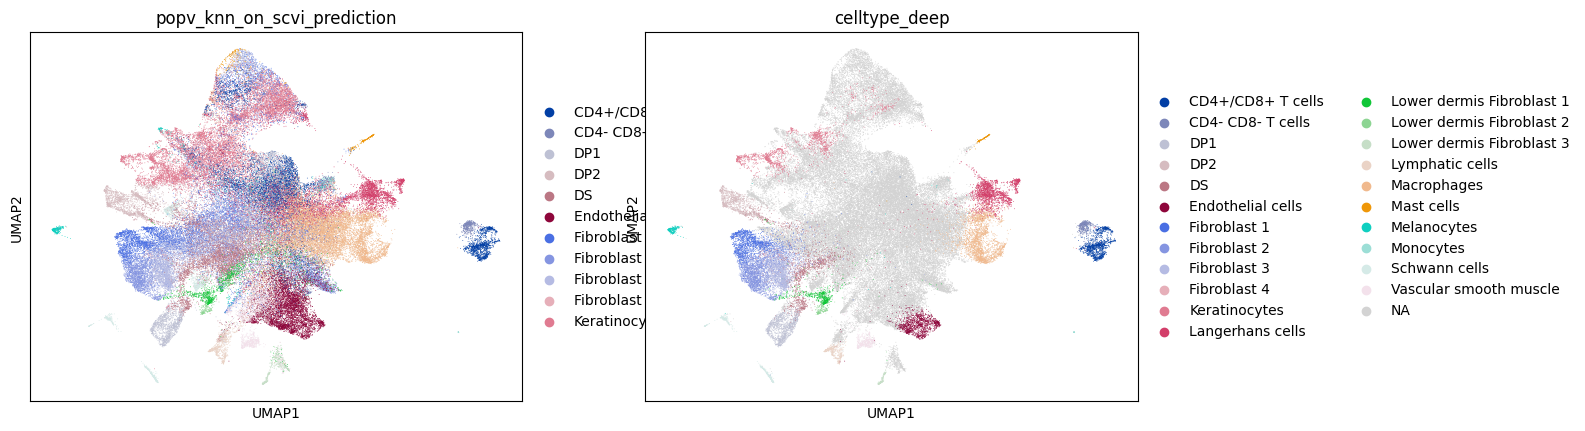

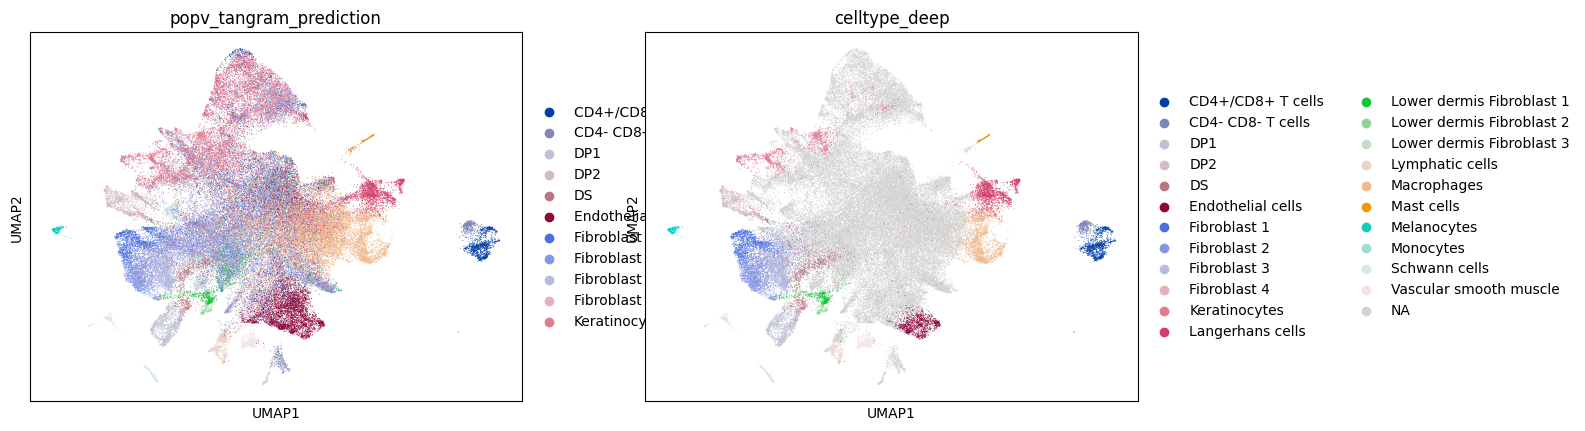

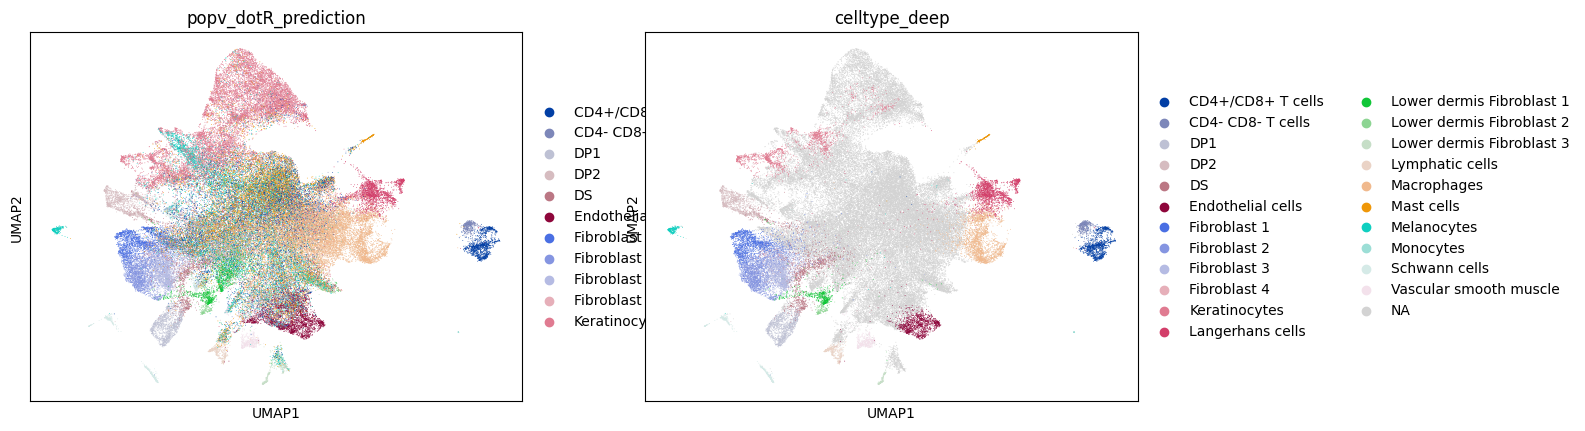

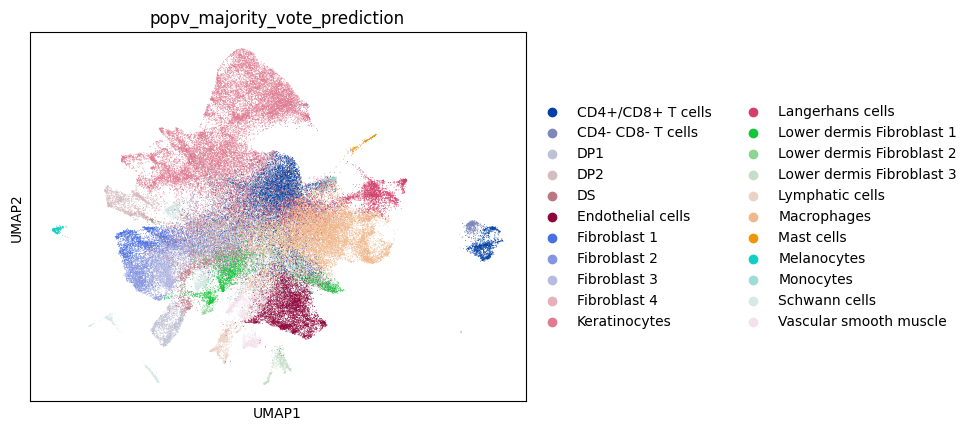

In [23]:
processed_adata.obsm["X_umap"] = processed_adata.obsm["X_scanvi_umap_popv"]
sc.pl.umap(
    processed_adata,
    color=[
        "popv_scanvi_prediction",
        "celltype_deep",
    ],
    ncols=2,
)
processed_adata.obsm["X_umap"] = processed_adata.obsm["X_scvi_umap_popv"]
sc.pl.umap(
    processed_adata,
    color=[
        "popv_knn_on_scvi_prediction",
        "celltype_deep",
    ],
    ncols=2,
)
processed_adata.obsm["X_umap"] = processed_adata.obsm["X_scvi_umap_popv"]
sc.pl.umap(
    processed_adata,
    color=[
        "popv_tangram_prediction",
        "celltype_deep",
    ],
    ncols=2,
)
processed_adata.obsm["X_umap"] = processed_adata.obsm["X_scvi_umap_popv"]
sc.pl.umap(
    processed_adata,
    color=[
        "popv_dotR_prediction",
        "celltype_deep",
    ],
    ncols=2,
)


processed_adata.obsm["X_umap"] = processed_adata.obsm["X_scvi_umap_popv"]
sc.pl.umap(
    processed_adata,
    color=[
        "popv_majority_vote_prediction"
    ],
    ncols=1,
)

In [29]:
processed_adata

AnnData object with n_obs × n_vars = 85344 × 474
    obs: 'scdbl_class', 'batch', 'condition', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'leiden_res_1.0', 'leiden_res_0.5', 'leiden_res_0.2', 'celltype', 'hash.ID', 'celltype_caro', 'celltype_deep', '_batch_annotation', '_labels_annotation', '_ref_subsample', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'cell_area', 'nucleus_area', 'region', 'Slide', 'n_counts', 'immune_pool', 'sample', 'leiden_igraph_res_1.0', 'leiden_igraph_res_2.0', '_dataset', 'popv_celltypist_prediction', 'popv_celltypist_prediction_probabilities'

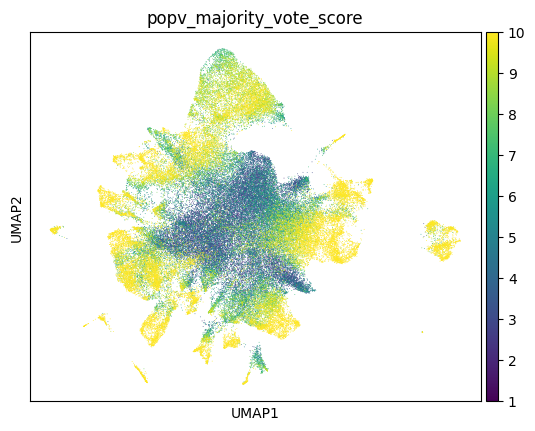

In [30]:
sc.pl.umap(
    processed_adata,
    color=[
        "popv_majority_vote_score",
    ],
    ncols=1,)

Making confusion matrix for popv_celltypist_prediction


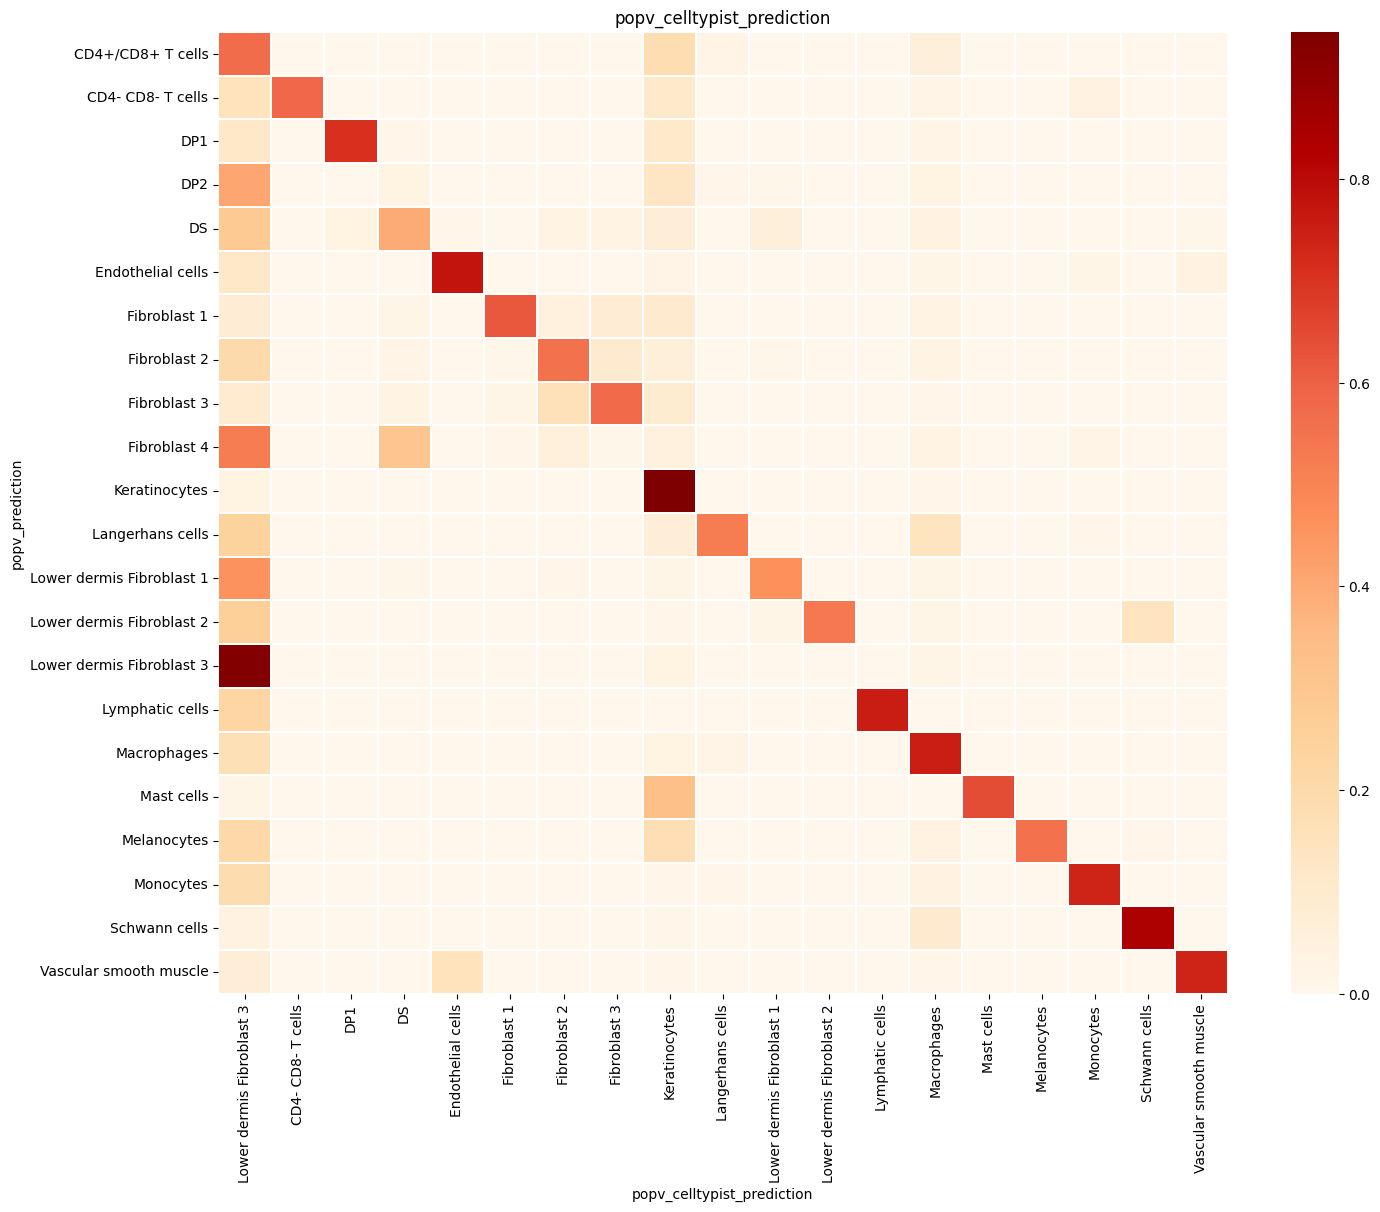

Making confusion matrix for popv_knn_on_bbknn_prediction


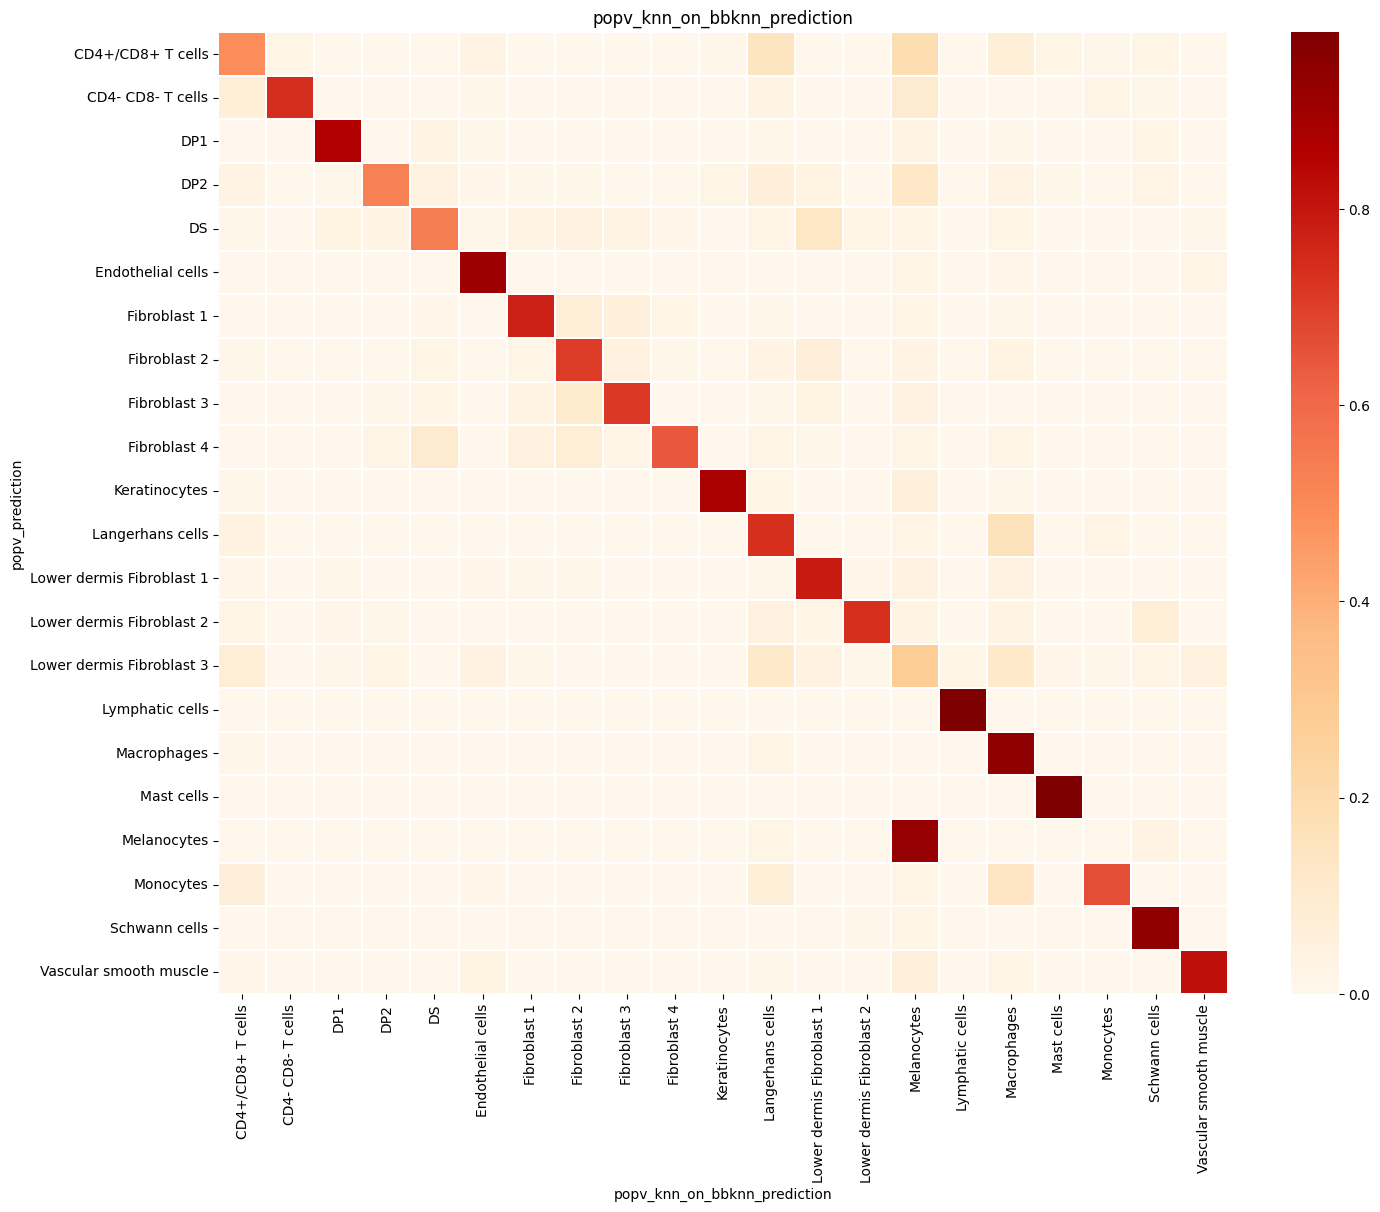

Making confusion matrix for popv_knn_on_harmony_prediction


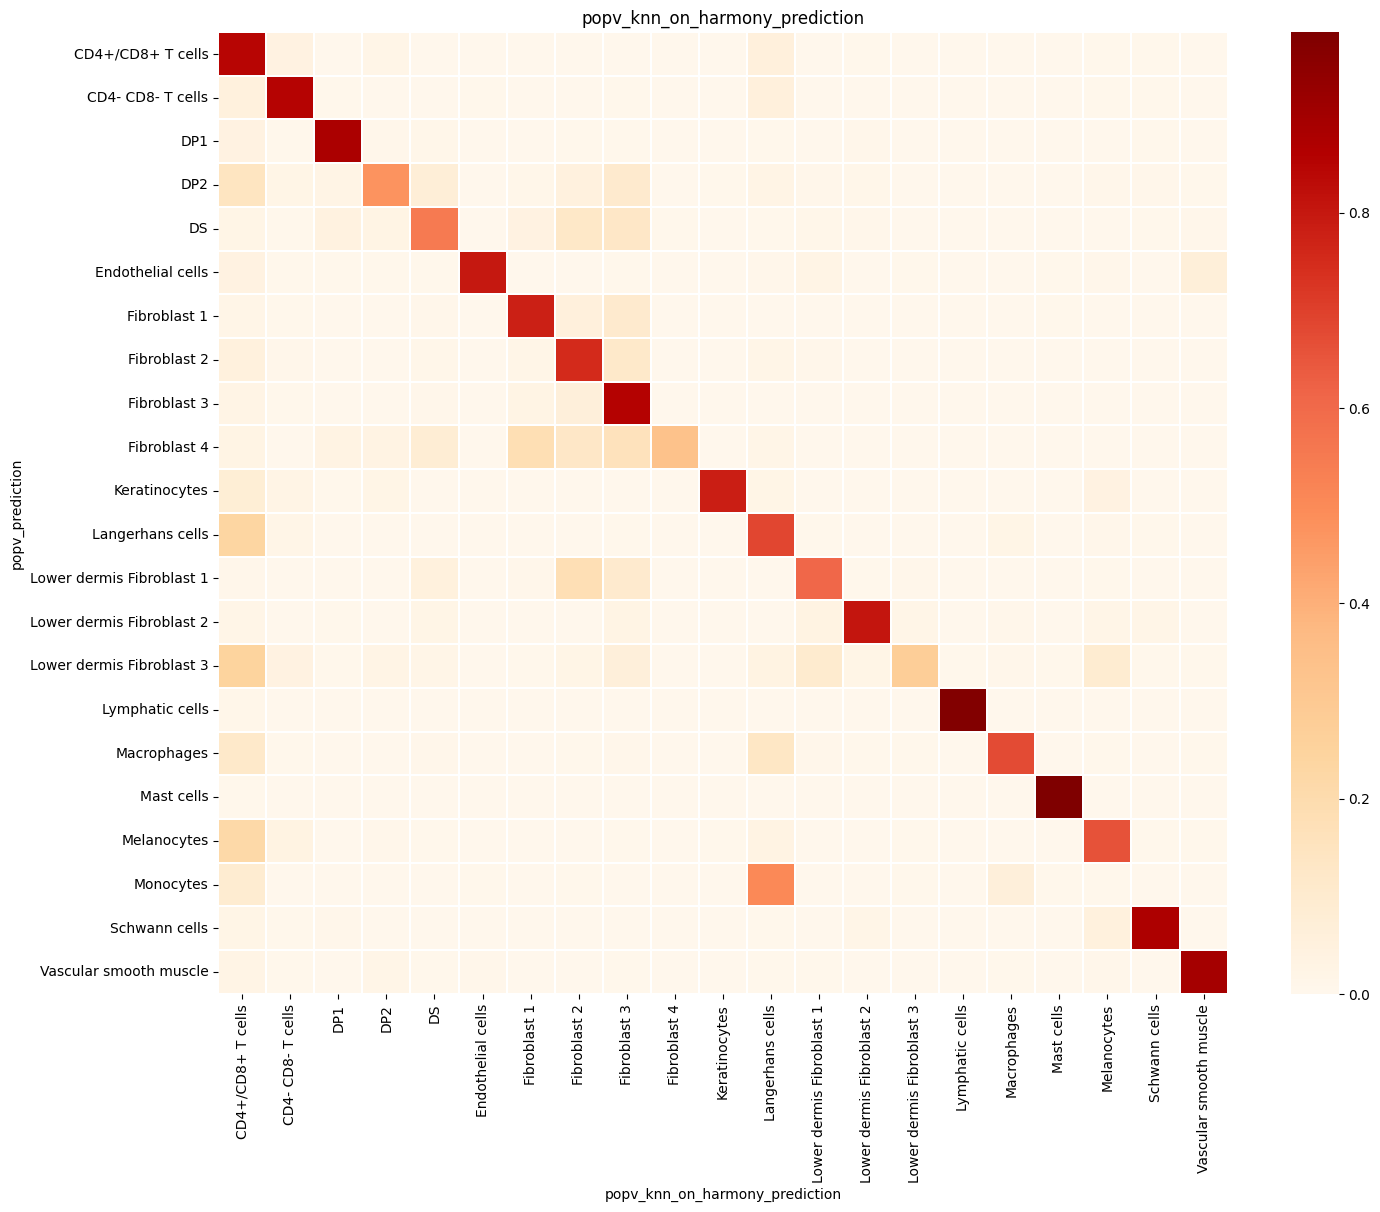

Making confusion matrix for popv_knn_on_scanorama_prediction


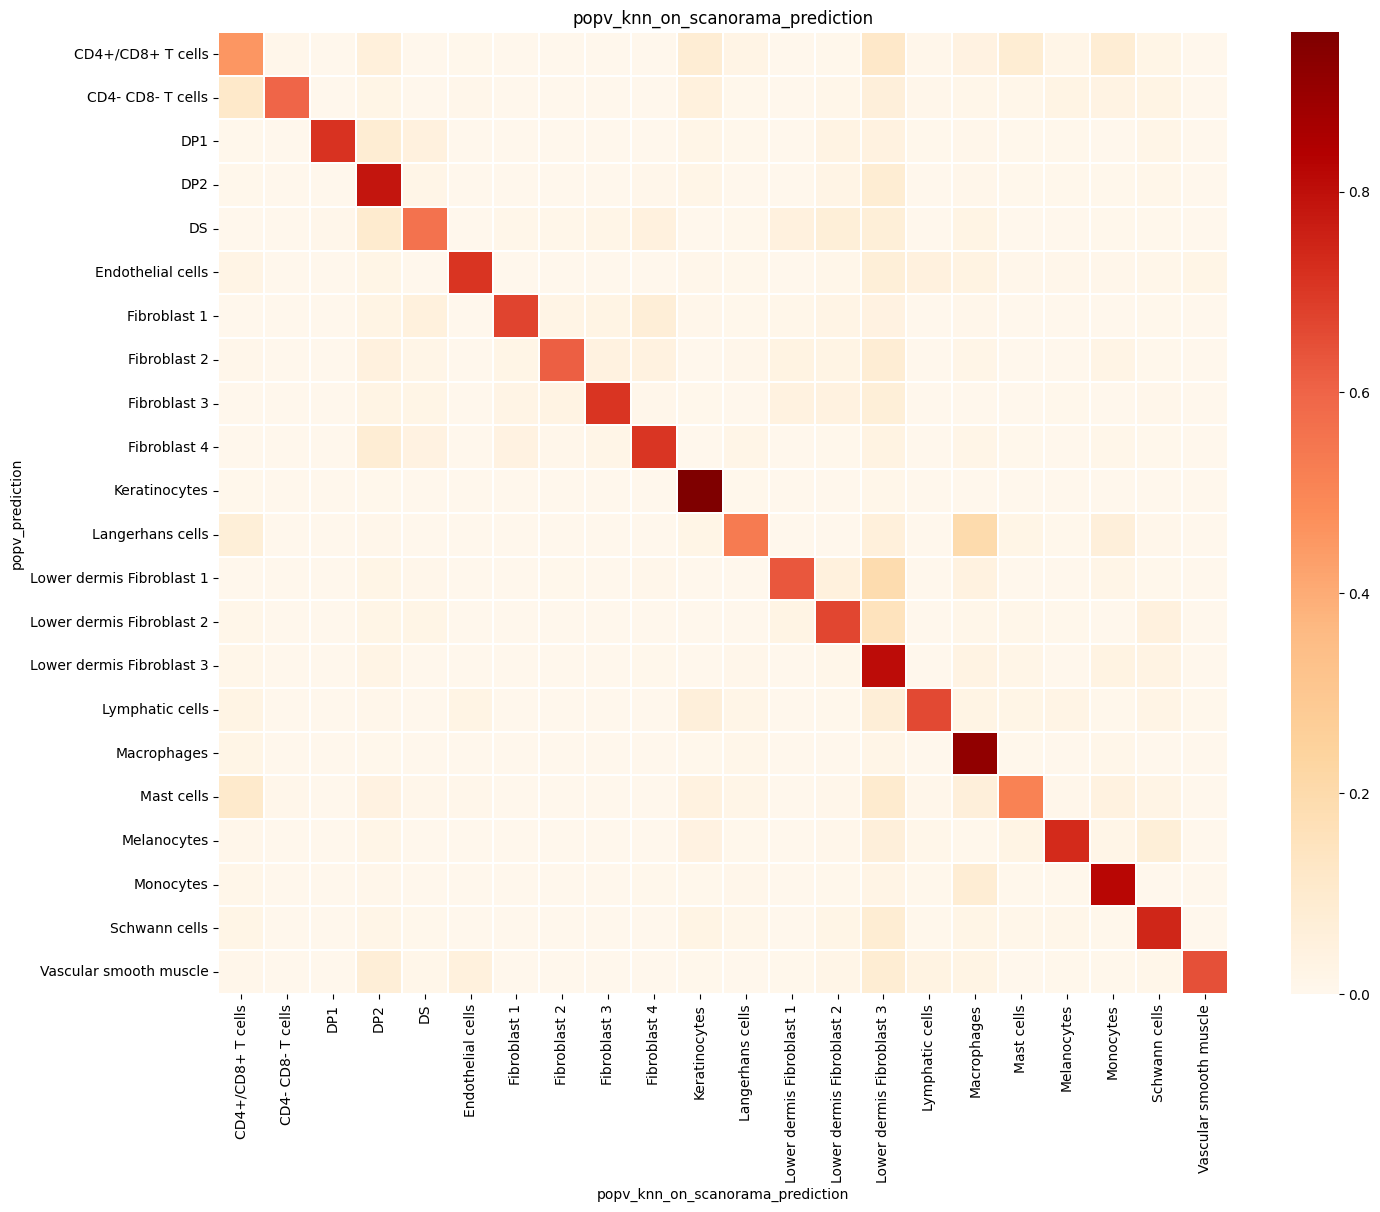

Making confusion matrix for popv_knn_on_scvi_prediction


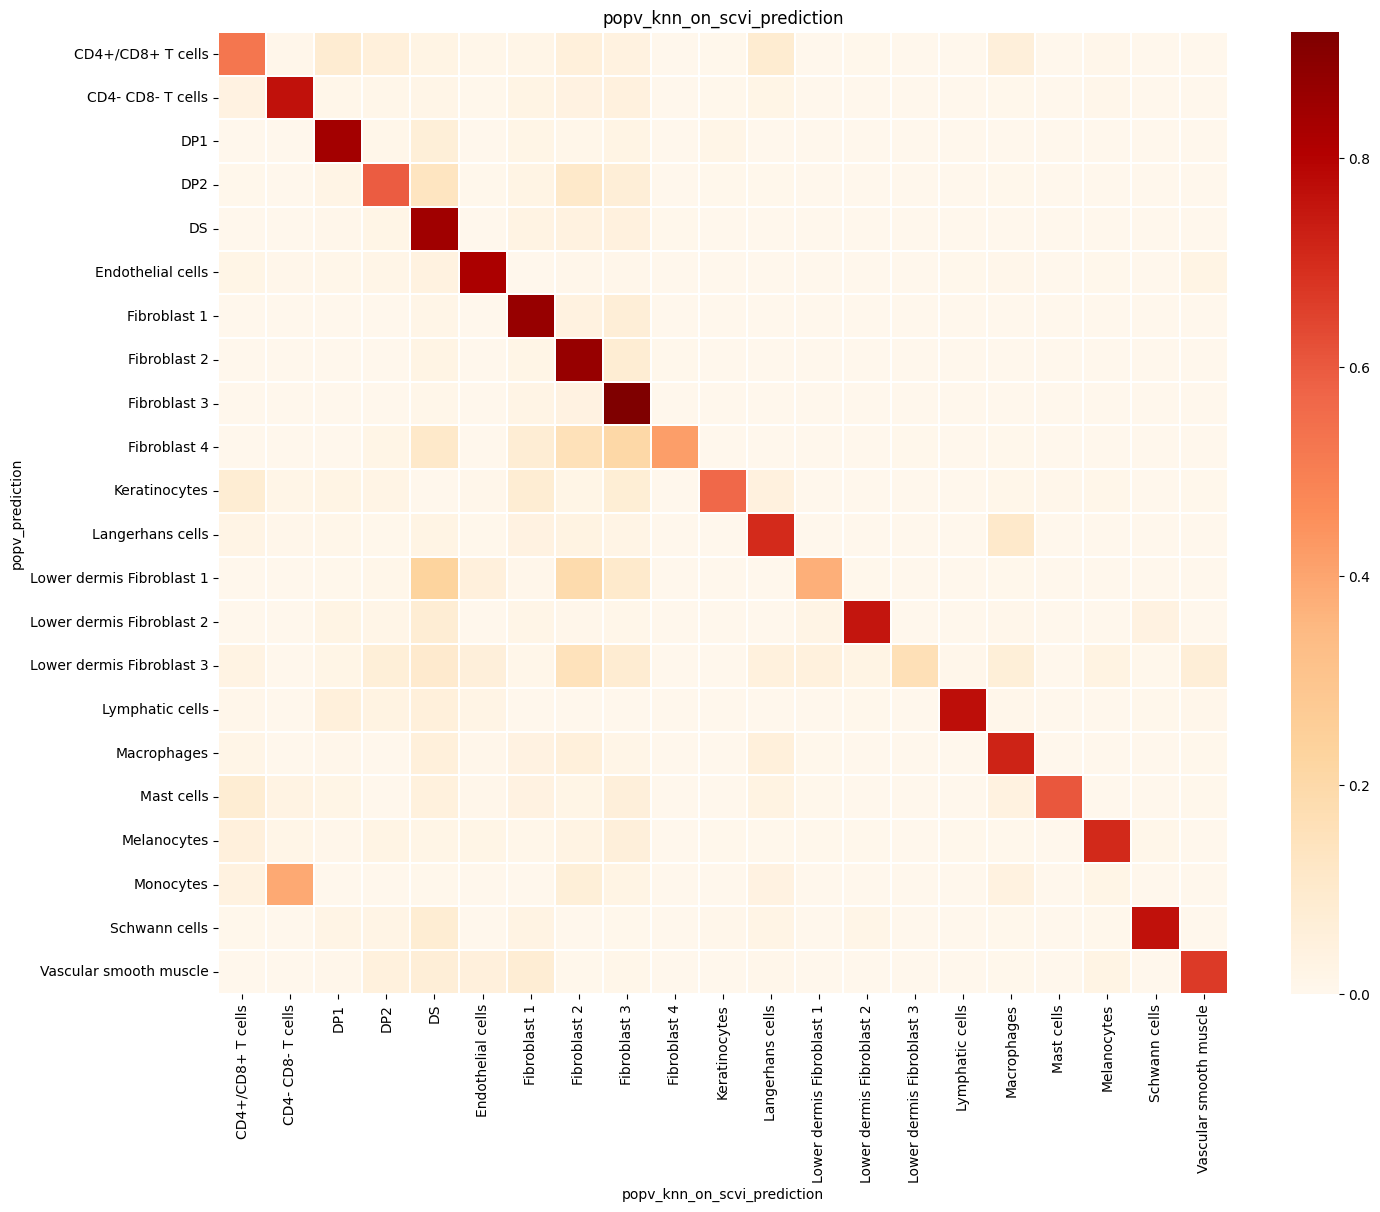

Making confusion matrix for popv_rf_prediction


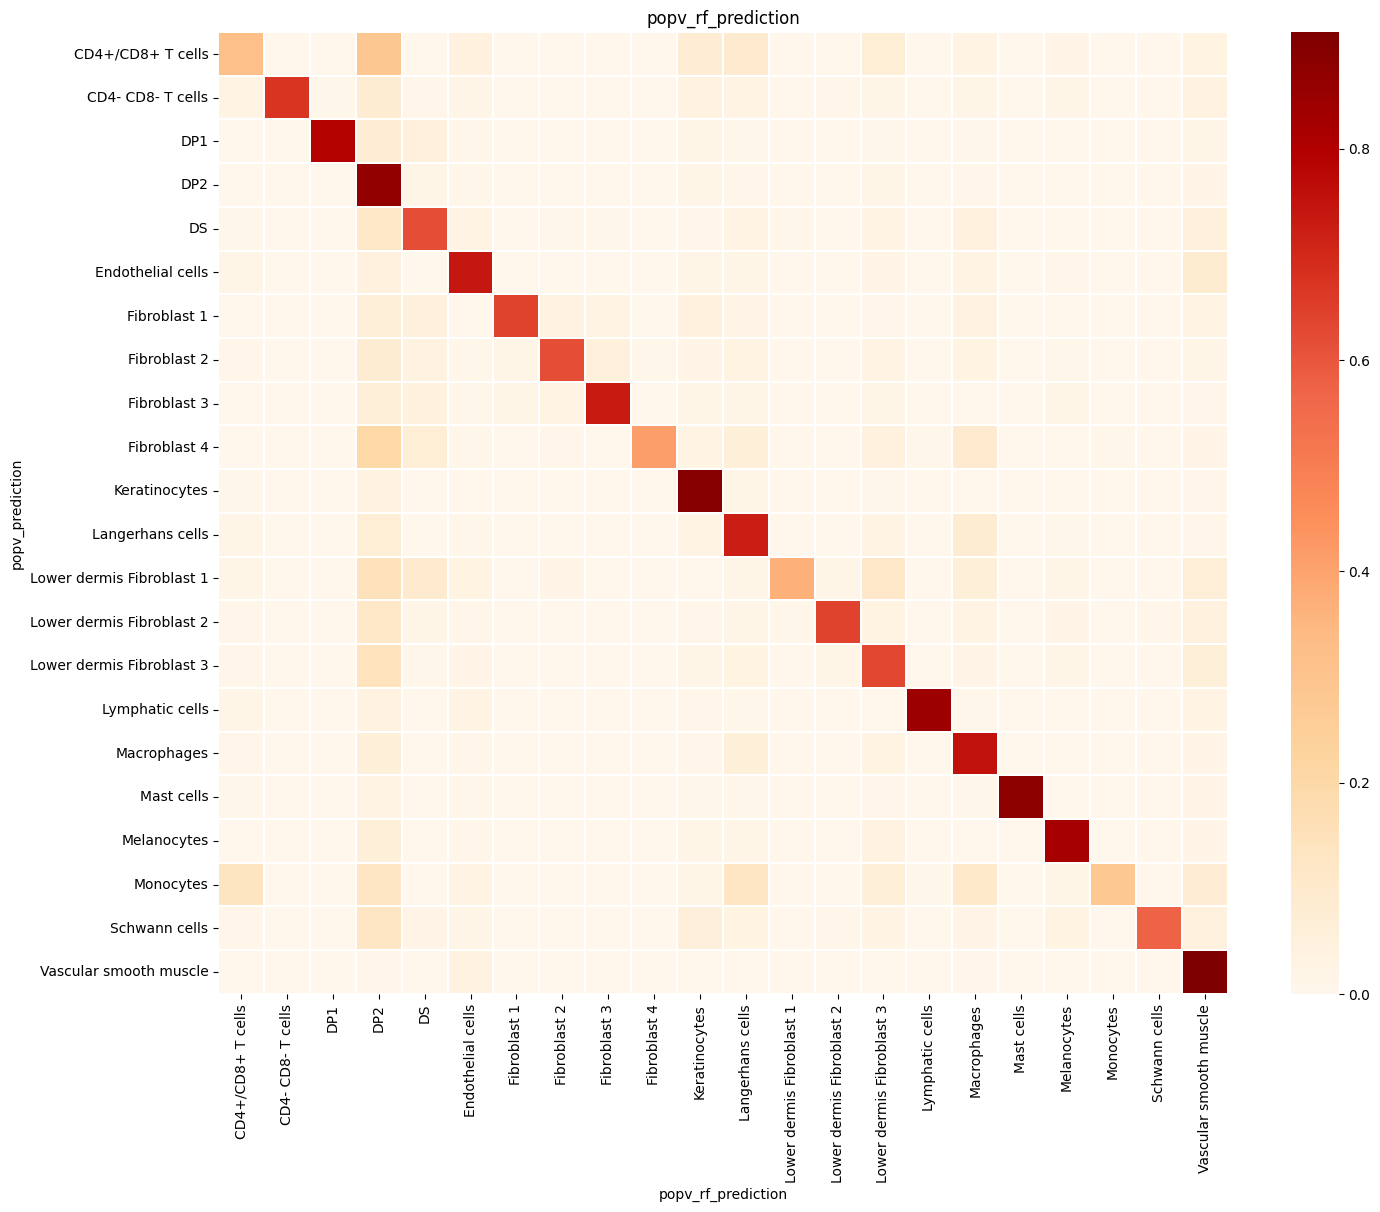

Making confusion matrix for popv_scanvi_prediction


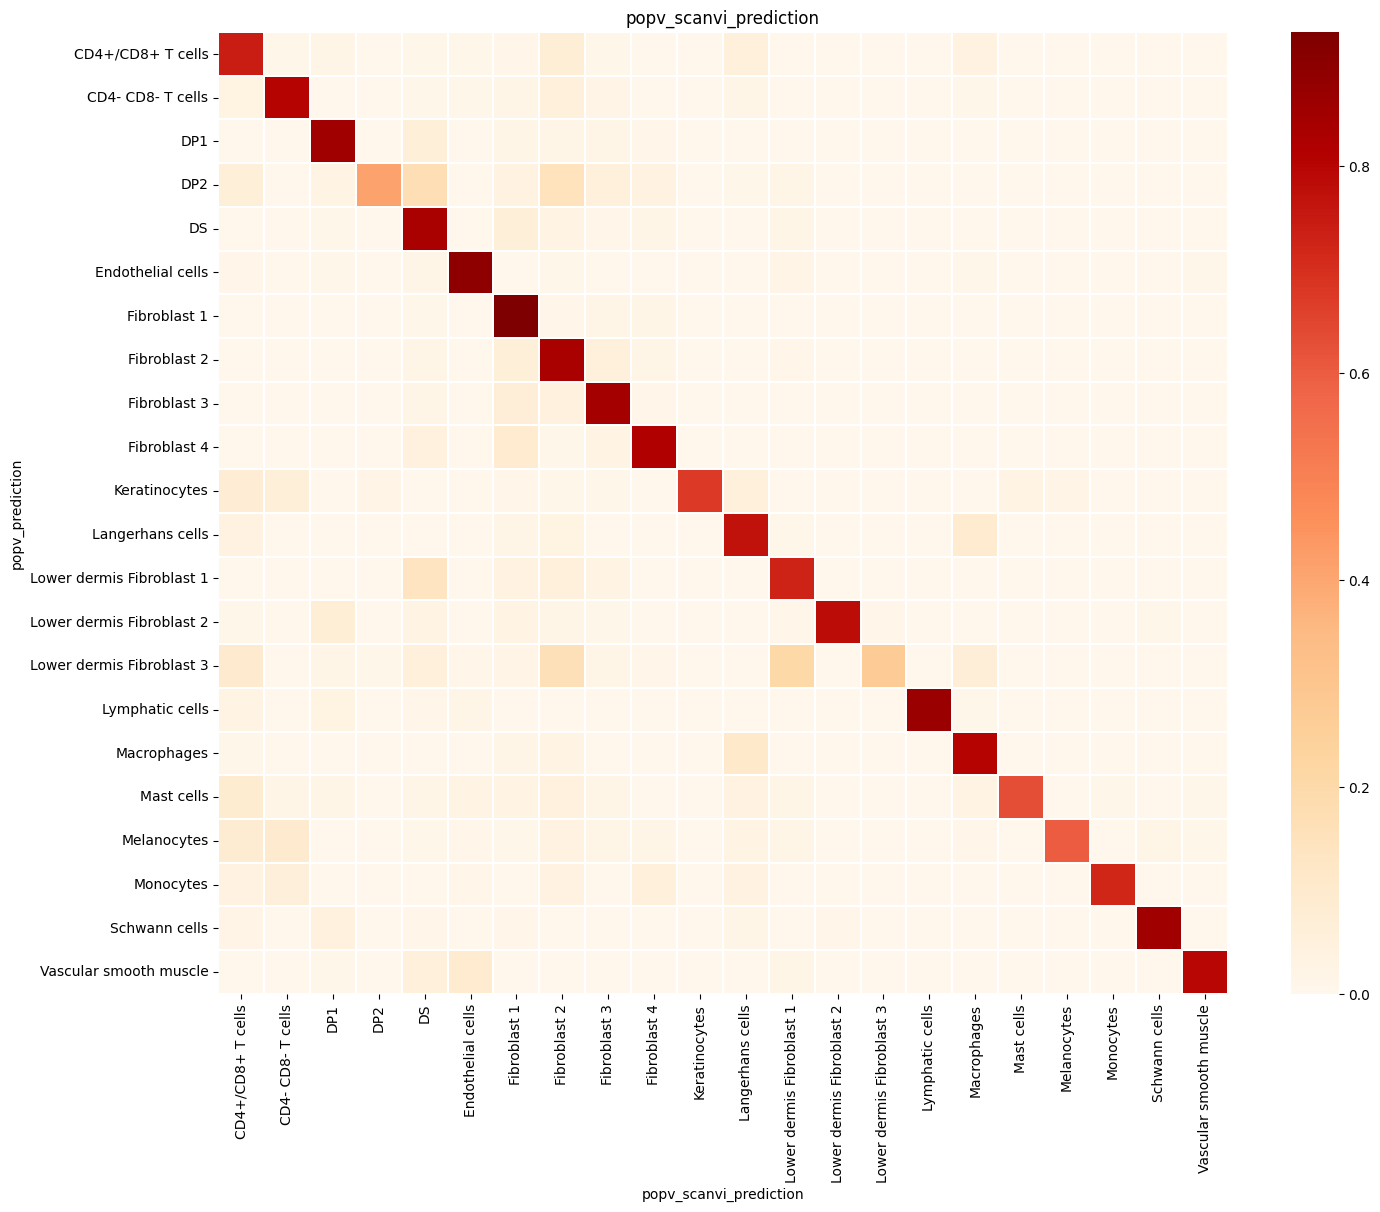

Making confusion matrix for popv_svm_prediction


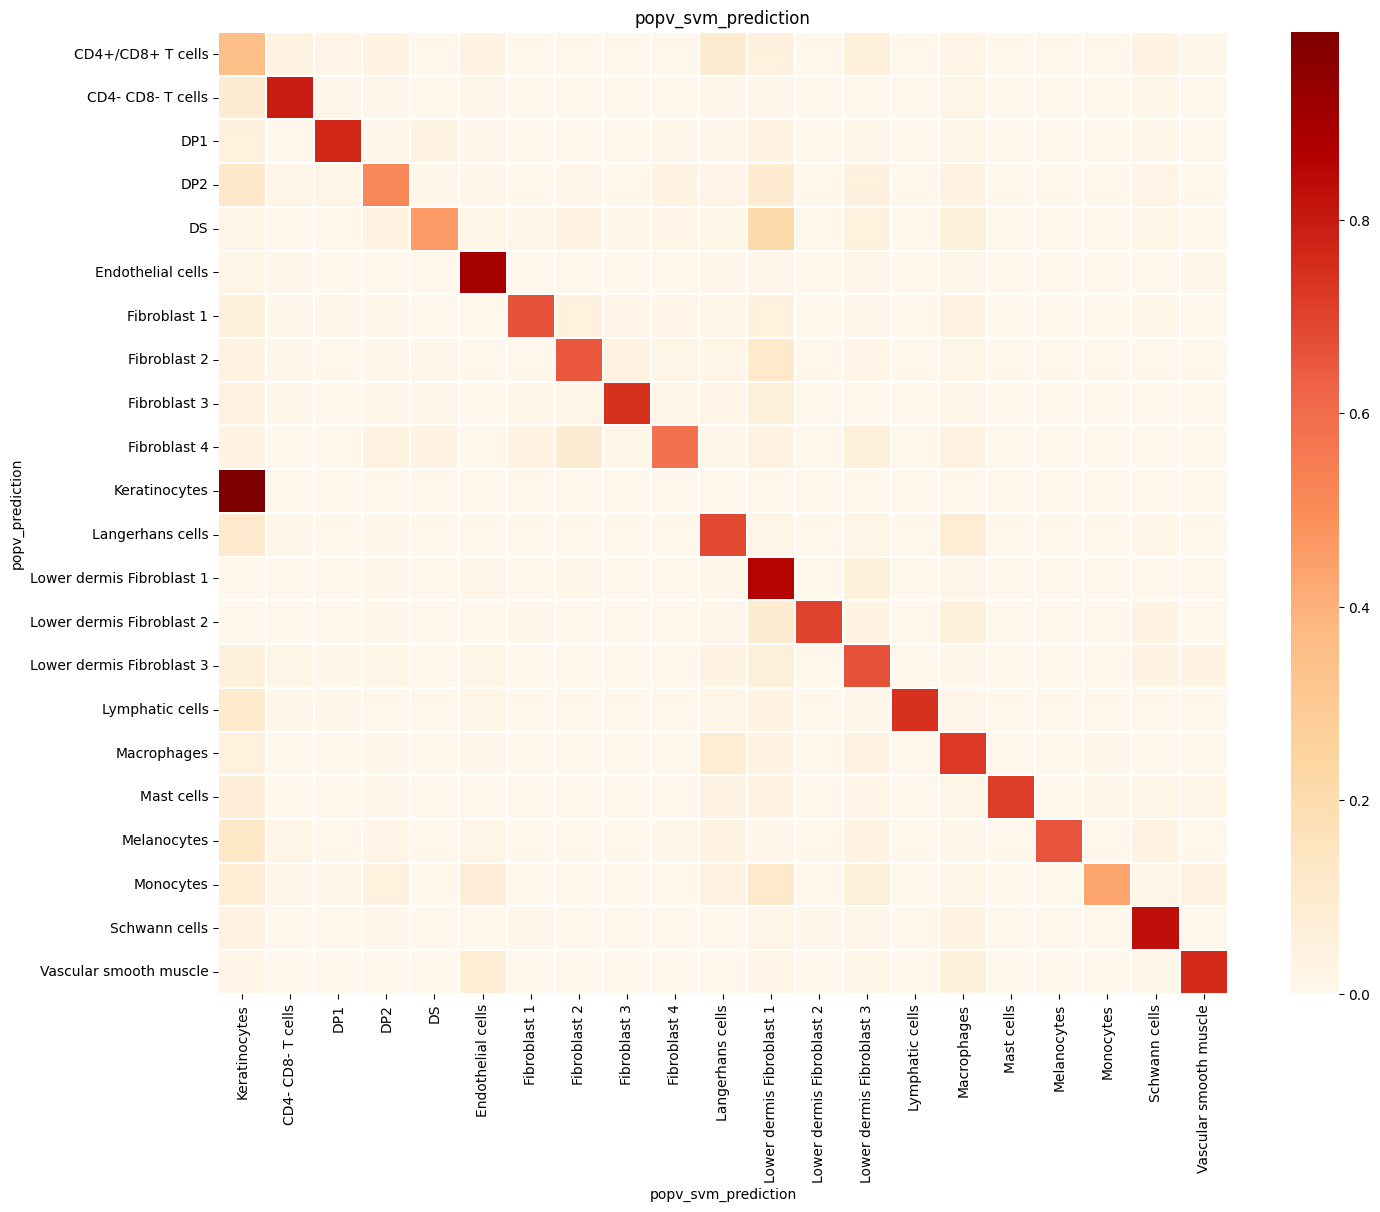

Making confusion matrix for popv_tangram_prediction


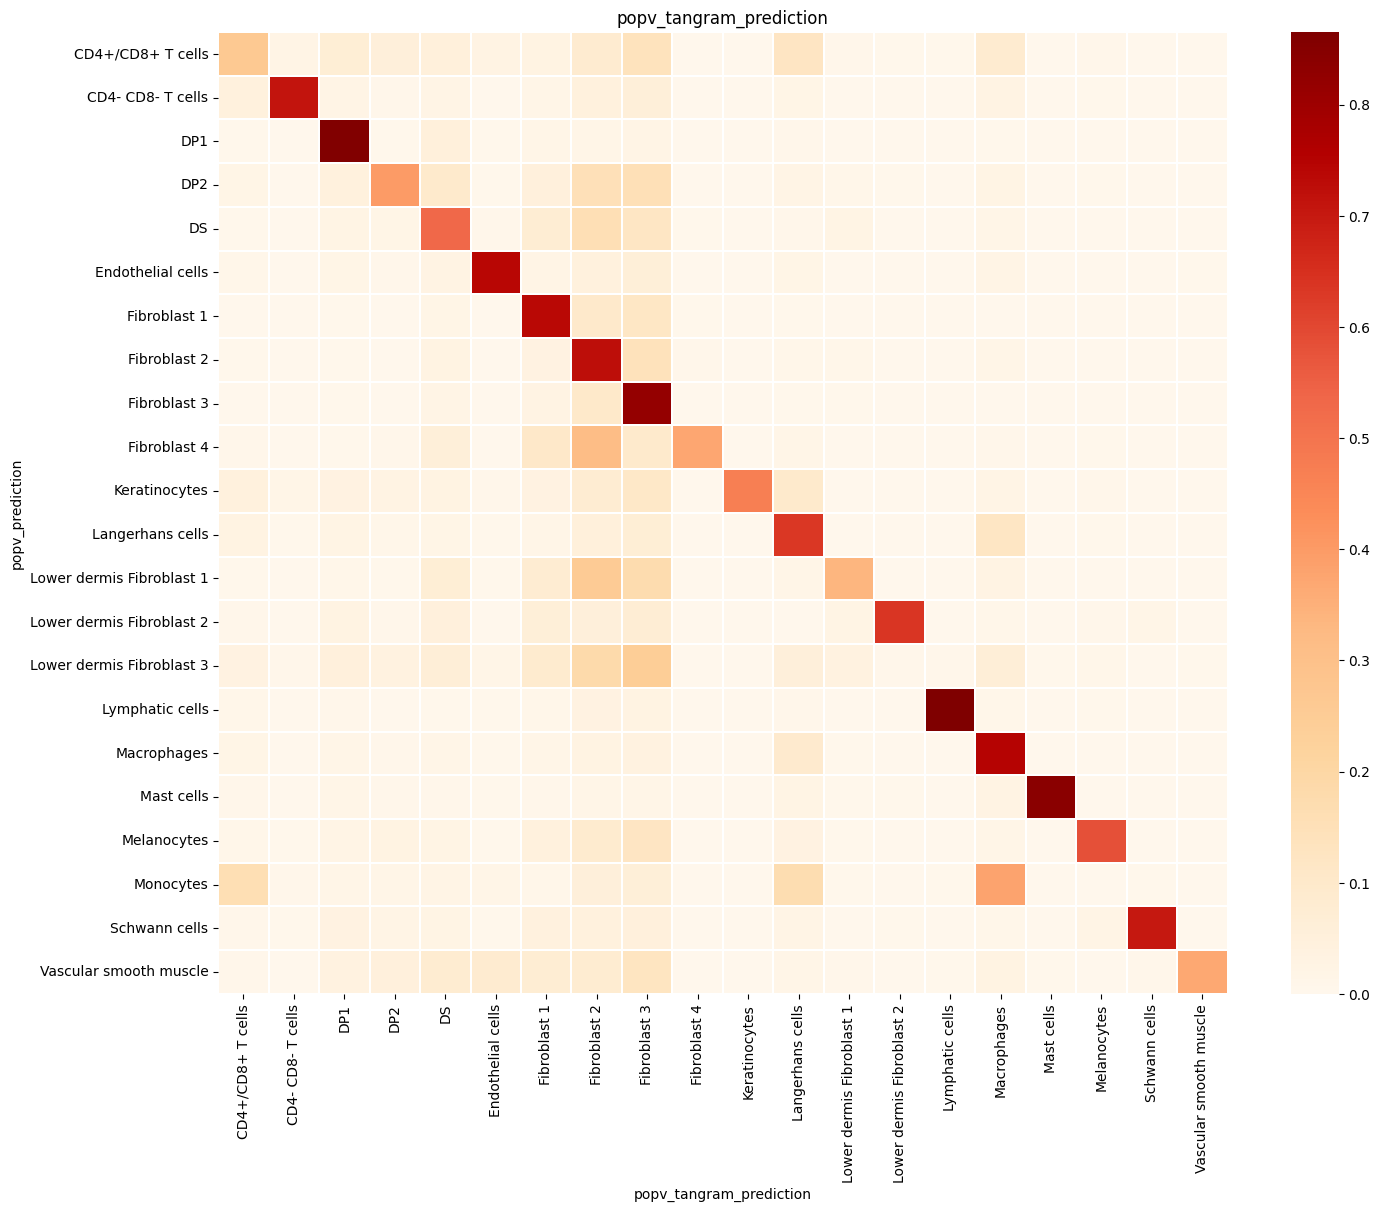

Making confusion matrix for popv_dotR_prediction


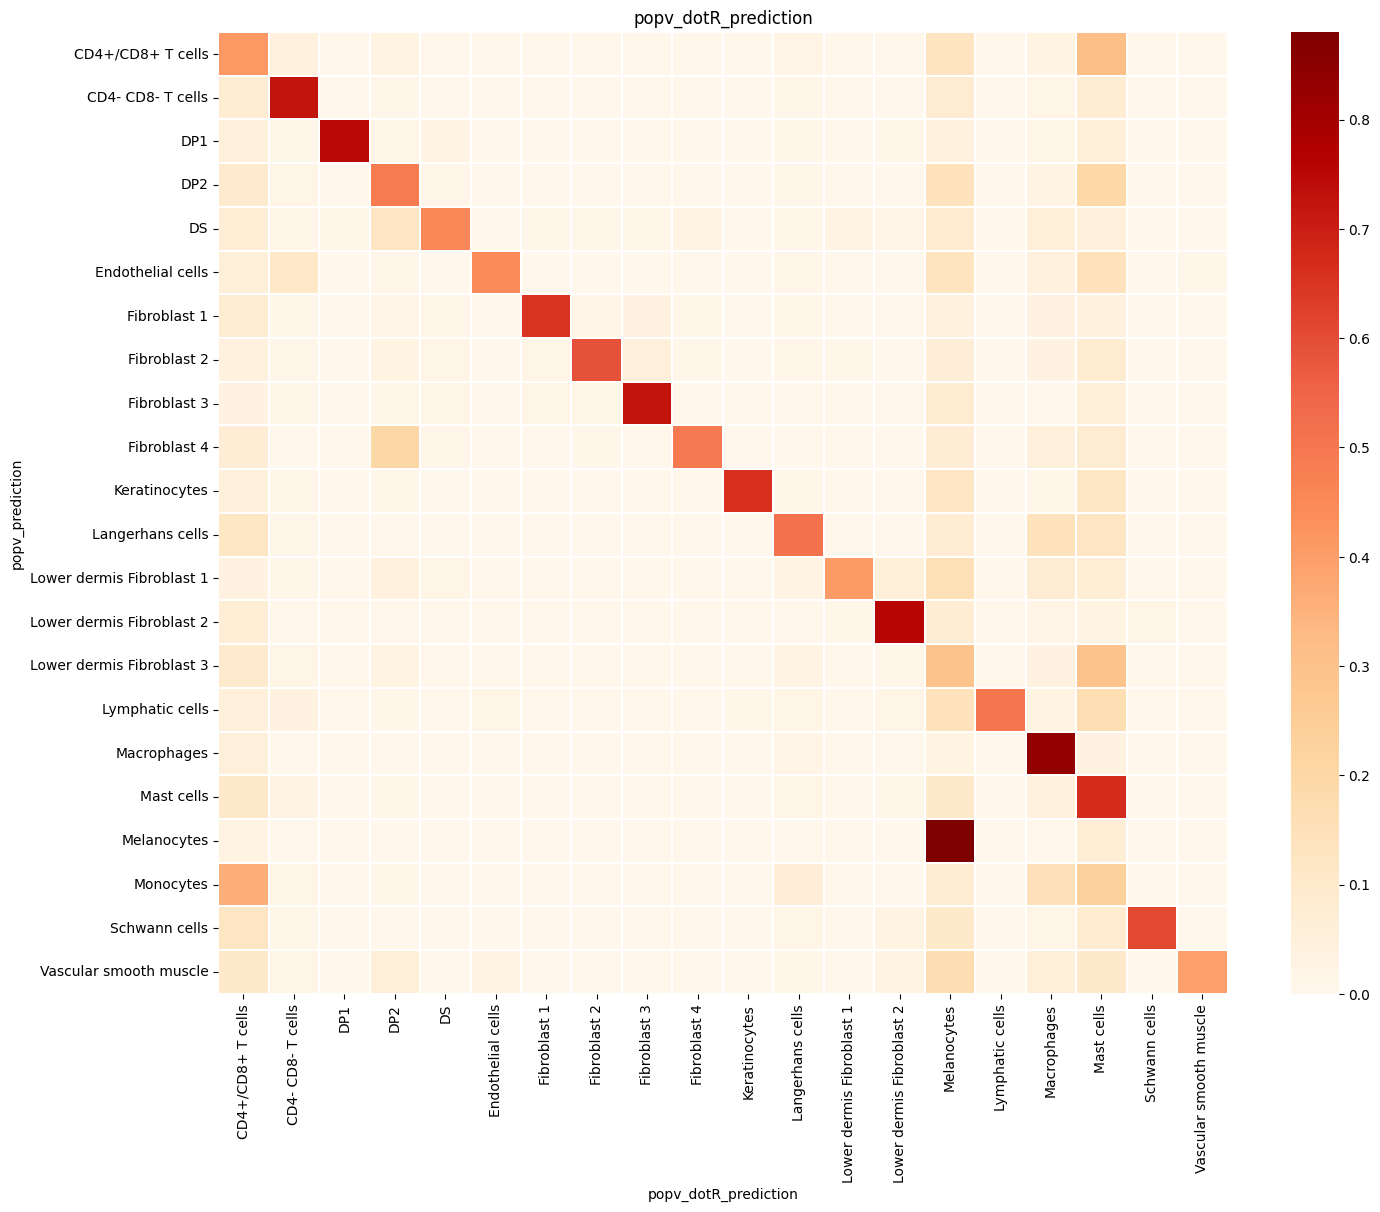

In [31]:
popv.visualization.make_agreement_plots(
    processed_adata,
    prediction_keys=processed_adata.uns["prediction_keys"],
    save_folder=output_folder)

In [155]:
# processed_adata.uns["prediction_keys"]=[
#  'popv_knn_on_bbknn_prediction',
#  'popv_knn_on_harmony_prediction',
#  'popv_knn_on_scanorama_prediction',
#  'popv_knn_on_scvi_prediction',
#  'popv_rf_prediction',
#  'popv_scanvi_prediction',
#  'popv_svm_prediction',
# 'popv_tangram_prediction']

popv.annotation.compute_consensus(processed_adata,prediction_keys=processed_adata.uns["prediction_keys"])

TypeError: '<' not supported between instances of 'float' and 'str'

<Axes: ylabel='Mean Agreement'>

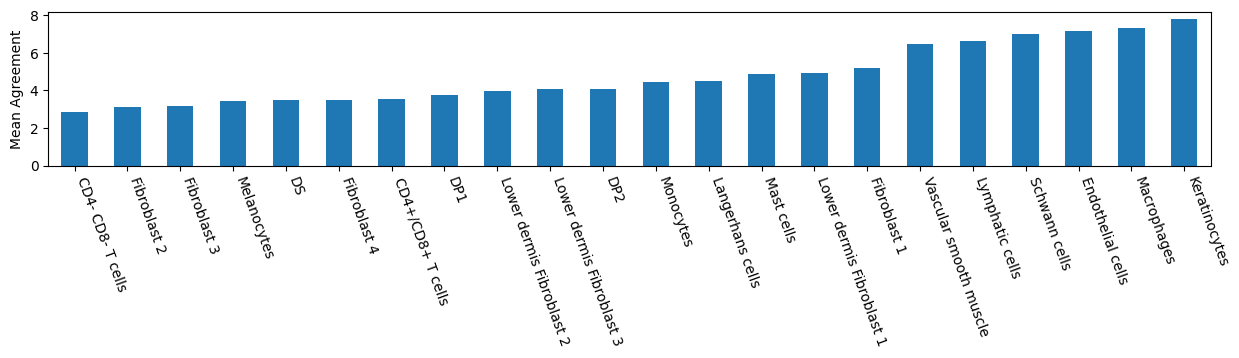

In [32]:
popv.visualization.agreement_score_bar_plot(processed_adata,popv_prediction_key='popv_majority_vote_prediction',consensus_score_key='popv_majority_vote_score)

<Axes: title={'center': 'PopV Prediction Score'}, xlabel='Score', ylabel='Frequency'>

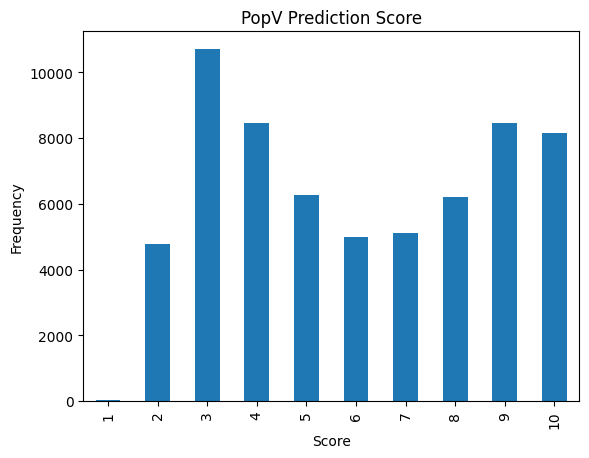

In [33]:
popv.visualization.prediction_score_bar_plot(
    processed_adata,popv_prediction_score='popv_majority_vote_score')

In [15]:
processed_adata.obs["popv_majority_vote_score"]

AAACCCAAGAGGTTAT-1-0     5
GTCTGTCCACTCCGGA-1-0     9
GTCTGTCGTCACAGTT-1-0    10
GTCTGTCGTGTTACAC-1-0     8
GTCTTTAAGCAACTTC-1-0    10
                        ..
jbpmbhaa-1               4
jbpmilng-1               2
jbppbifm-1               3
jcahhcpm-1               8
jbddegbg-1               4
Name: popv_majority_vote_score, Length: 85344, dtype: int64

In [16]:
processed_adata.obs[["popv_majority_vote_score"]].to_csv(
    "skin_expansion_xenium/Majority_voting_score.csv"
)

In [13]:
popv.visualization.prediction_score_bar_plot(
    processed_adata,popv_prediction_score='popv_majority_vote_score')

NameError: name 'popv' is not defined

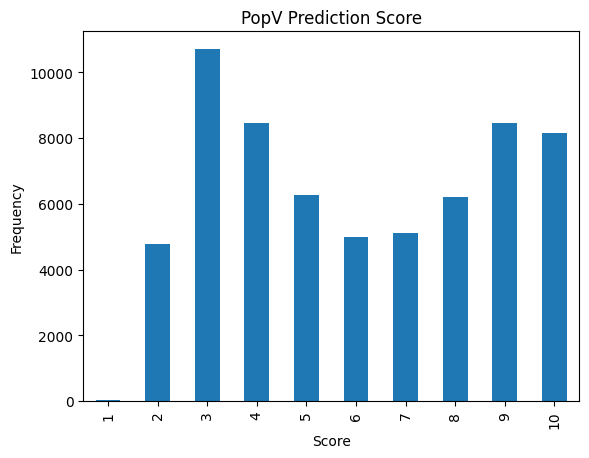

In [241]:
import os

# Generate the plot and get the axis object
ax = popv.visualization.prediction_score_bar_plot(
    processed_adata, popv_prediction_score='popv_majority_vote_score'
)

# Get the figure object from the axis and save it as an SVG
plot_filename = 'skin_expansion_xenium/Majority_voting_score.svg'
os.makedirs(os.path.dirname(plot_filename), exist_ok=True)  # Ensure the directory exists
ax.get_figure().savefig(plot_filename, dpi=200, bbox_inches='tight', transparent=True, format='svg')


<Axes: ylabel='Celltype Abundance'>

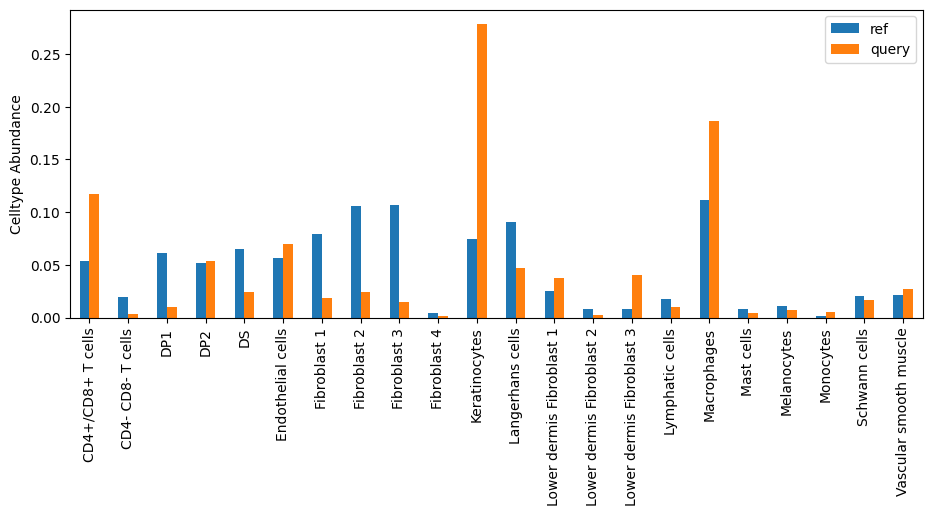

In [34]:
popv.visualization.celltype_ratio_bar_plot(processed_adata,popv_prediction='popv_majority_vote_prediction')

In [33]:
import pandas as pd

def add_matching_obs(spatial_adata, processed_adata):
    """
    Adds matching observations from processed AnnData to spatial AnnData using pd.concat.
    
    Parameters
    ----------
    spatial_adata : anndata.AnnData
        The original spatial AnnData object.
    processed_adata : anndata.AnnData
        The processed AnnData object containing updated obs to be added.
        
    Returns
    -------
    spatial_adata : anndata.AnnData
        The updated spatial AnnData with added obs fields.
    """
    # Select new columns from processed AnnData that are not in spatial AnnData, and only the matching indices
    new_columns = processed_adata.obs.loc[
        processed_adata.obs.index.intersection(spatial_adata.obs.index),
        processed_adata.obs.columns.difference(spatial_adata.obs.columns)
    ]

    # Concatenate the new columns to the spatial obs DataFrame
    spatial_adata.obs = pd.concat([spatial_adata.obs, new_columns], axis=1)

    return spatial_adata

In [34]:
spatial_data = add_matching_obs(st_data, processed_adata)

In [35]:
spatial_data

AnnData object with n_obs × n_vars = 72636 × 474
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'Slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'n_counts', 'immune_pool', 'condition', 'sample', 'leiden_igraph_res_1.0', 'leiden_igraph_res_2.0', '_batch_annotation', '_dataset', '_labels_annotation', '_ref_subsample', '_scvi_batch', '_scvi_labels', 'batch', 'celltype', 'celltype_caro', 'celltype_deep', 'hash.ID', 'leiden_res_0.2', 'leiden_res_0.5', 'leiden_res_1.0', 'log1p_total_counts_hb', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'mt_outlier', 'outlier', 'pct_counts_hb', 'pct_counts_mt', 'pct_counts_ribo', 'popv_celltypist_prediction', 'popv_celltypist_prediction_probabilities', 'popv_dotR_prediction', 'popv_dotR_prediction_score', 

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib_scalebar.scalebar import ScaleBar
from sklearn.preprocessing import MinMaxScaler

pixel_size_x = 0.2125  # microns per pixel for x-axis
pixel_size_y = 0.2125  # microns per pixel for y-axis

def rotate_point(point, origin, angle):
    """Rotate a point counterclockwise by a given angle around a given origin."""
    angle = np.radians(angle)
    ox, oy = origin
    px, py = point
    qx = ox + np.cos(angle) * (px - ox) - np.sin(angle) * (py - oy)
    qy = oy + np.sin(angle) * (px - ox) + np.cos(angle) * (py - oy)
    return qx, qy

# Function to add a scale bar to the axis
def add_scale_bar_to_ax(ax, size_of_one_pixel, units="um", length_fraction=0.2):
    from matplotlib_scalebar.scalebar import ScaleBar
    scalebar = ScaleBar(
        size_of_one_pixel,pad=-4.5,border_pad=2,
        units=units,
        fixed_value=100,
        length_fraction=length_fraction,
        dimension="si-length",
        location="lower right",  # Adjust position closer to the bottom
        frameon=False,
        scale_loc="bottom"  # Place the scale line directly below the text
    )
    scalebar.box_alpha = 1  # Make the background fully transparent
    scalebar.linewidth = 1  # Increase the thickness of the scale bar
    ax.add_artist(scalebar)

    
sample_params = {
    # 'control_1_0': {'angle': -110, 'spot_size': 0.15},
    'control_2_0': {'angle': -110, 'spot_size': 0.15},
    'control_2_1': {'angle': -100, 'spot_size': 0.1},
    # 'control_4_0': {'angle': 0, 'spot_size': 0.125},
    'control_5_0': {'angle': 180, 'spot_size': 0.125},
    'control_4_1': {'angle': -10, 'spot_size': 0.125},
    # 'control_5_1': {'angle': -185, 'spot_size': 0.125},
}

# Define the color map for cell types
celltype_cmap = { "Fibroblast 3": "#FCBA78",
"Fibroblast 2": "#AEC7E8",
"DP1": "#269E68",
"Fibroblast 1": "#B6BD61",
"DP2": "#8C574C",
"Lower dermis Fibroblast 1": "#D87AB1",
"Fibroblast 4" : "#D62928",
"Lower dermis Fibroblast 2" : "#1DBFCF",
"Lower dermis Fibroblast 4" : "#262B66",
"Lower dermis Fibroblast 3" : "#F7F74D", 
"Macrophages":"#B6BD61",
"DS" : "#8559A5",
"Keratinocytes":"#D19CFF",  
"Langerhans cells":"#8C574C",
"CD4+/CD8+ T cells":"#FFFA4D",
"Endothelial cells":"#269E68",
"CD4- CD8- T cells":"#1D2451",
"Schwann cells":"#9DD089",
"Lymphatic cells":"#D87AB1",
"Vascular smooth muscle":"#F69696",
"Monocytes":"#FCBA78",
"Melanocytes":"#AEC7E8",
"Mast cells":"#1DBFCF"}

group_sets = [
    ['Keratinocytes', 'Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4'],
    ['Keratinocytes', 'Lower dermis Fibroblast 1', 'Lower dermis Fibroblast 2', 'Lower dermis Fibroblast 3', 'Lower dermis Fibroblast 4'],
    ['Keratinocytes', 'DP1', 'DP2', 'DS']
]

# print(spatial_data.obs['popv_majority_vote_prediction'].unique())

In [46]:
spatial_data[spatial_data.obs['popv_scanvi_prediction_probabilities']>0.9]

View of AnnData object with n_obs × n_vars = 49173 × 474
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'Slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'n_counts', 'immune_pool', 'condition', 'sample', 'leiden_igraph_res_1.0', 'leiden_igraph_res_2.0', '_batch_annotation', '_dataset', '_labels_annotation', '_ref_subsample', '_scvi_batch', '_scvi_labels', 'batch', 'celltype', 'celltype_caro', 'celltype_deep', 'hash.ID', 'leiden_res_0.2', 'leiden_res_0.5', 'leiden_res_1.0', 'log1p_total_counts_hb', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'mt_outlier', 'outlier', 'pct_counts_hb', 'pct_counts_mt', 'pct_counts_ribo', 'popv_celltypist_prediction', 'popv_celltypist_prediction_probabilities', 'popv_dotR_prediction', 'popv_dotR_prediction_

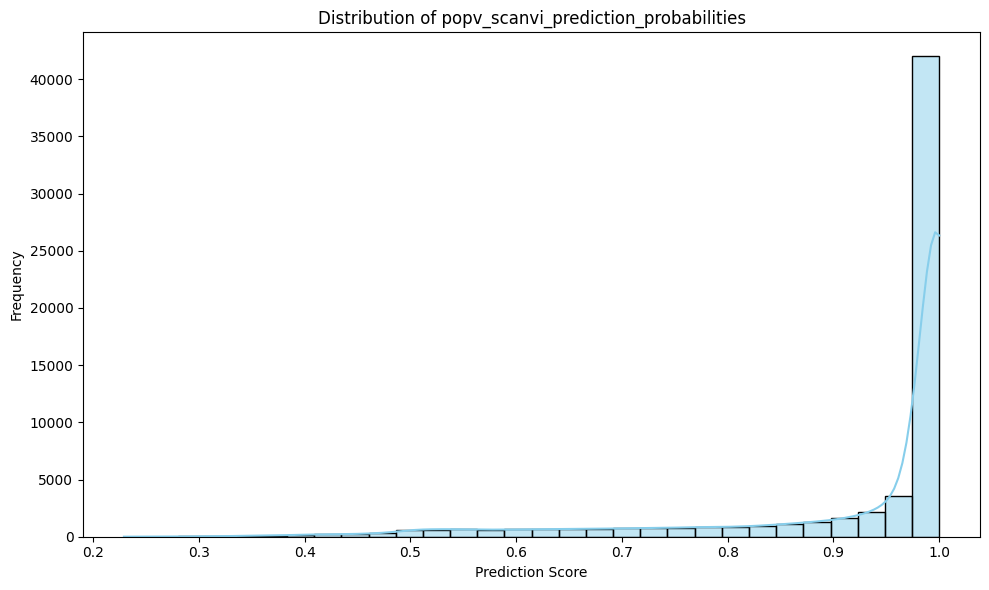

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the column with prediction probabilities, excluding NaN values
prediction_scores = spatial_data.obs['popv_scanvi_prediction_probabilities'].dropna()

# Plot the distribution of prediction scores using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(prediction_scores, kde=True, bins=30, color='skyblue')

# Customize the plot
plt.title('Distribution of popv_scanvi_prediction_probabilities')
plt.xlabel('Prediction Score')
plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()


In [41]:
processed_adata.uns['prediction_keys']

array(['popv_celltypist_prediction', 'popv_knn_on_bbknn_prediction',
       'popv_knn_on_harmony_prediction',
       'popv_knn_on_scanorama_prediction', 'popv_knn_on_scvi_prediction',
       'popv_rf_prediction', 'popv_scanvi_prediction',
       'popv_svm_prediction', 'popv_tangram_prediction',
       'popv_dotR_prediction'], dtype=object)

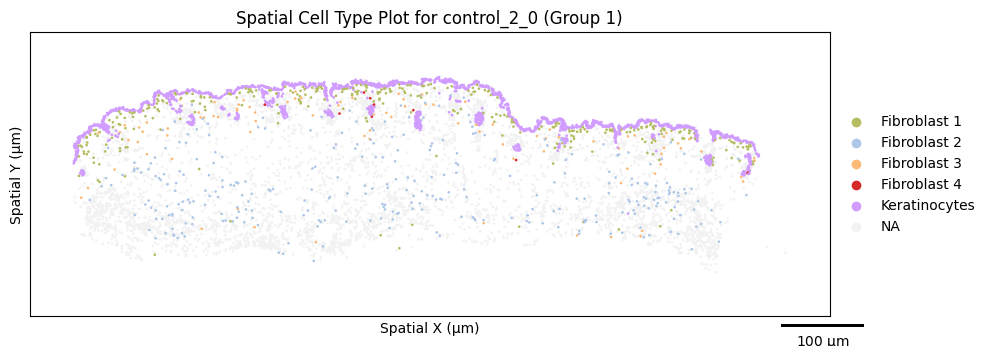

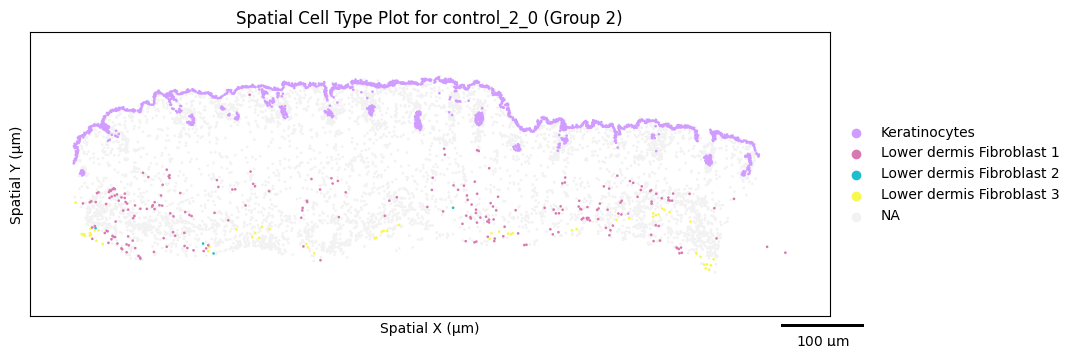

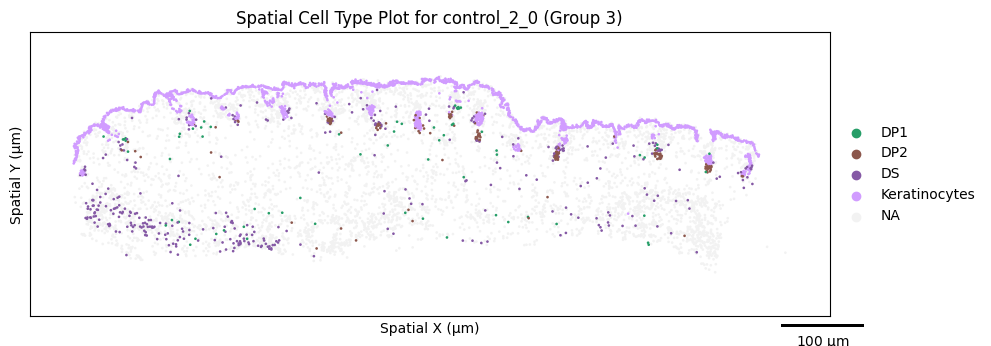

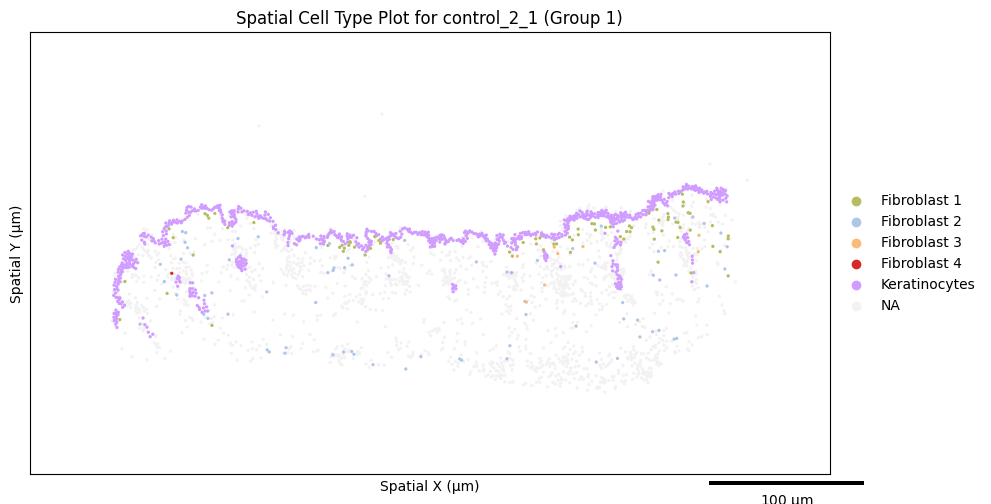

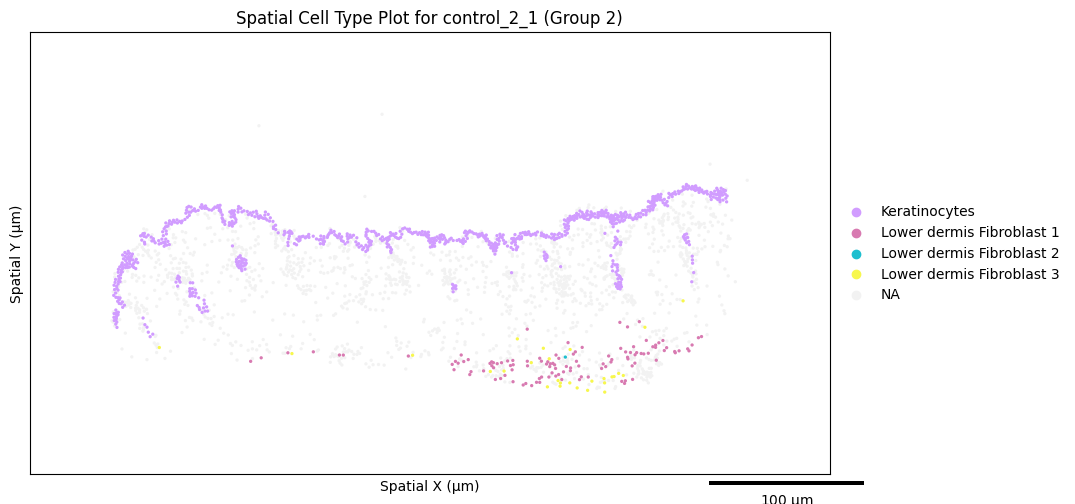

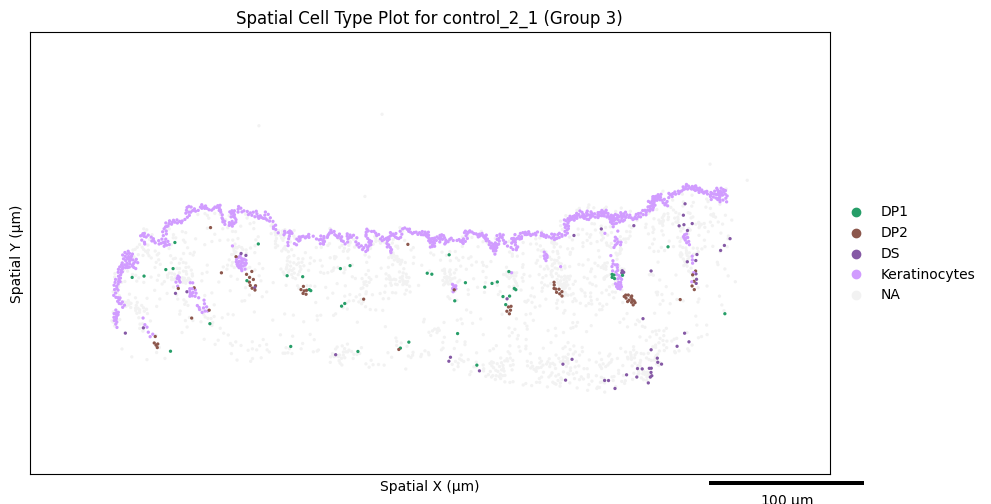

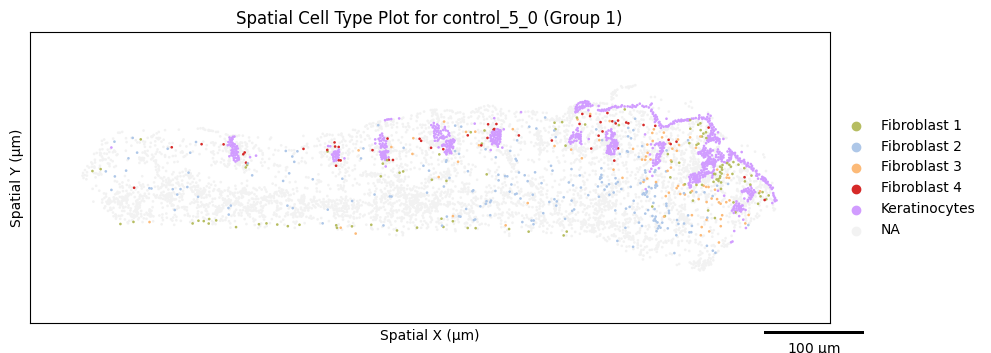

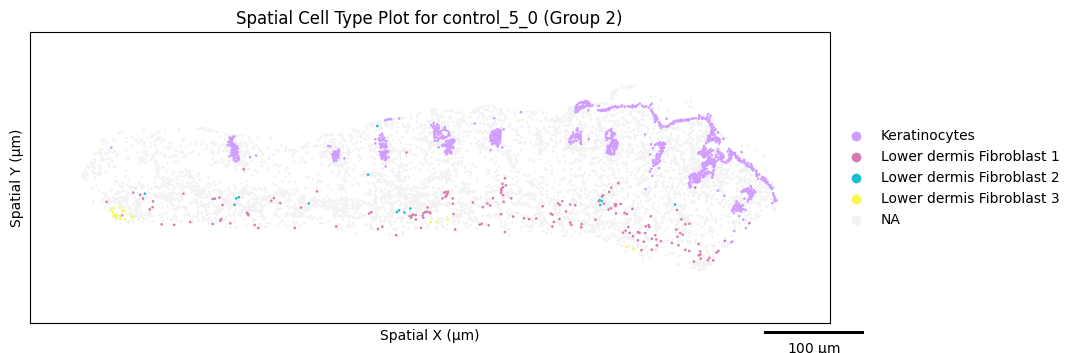

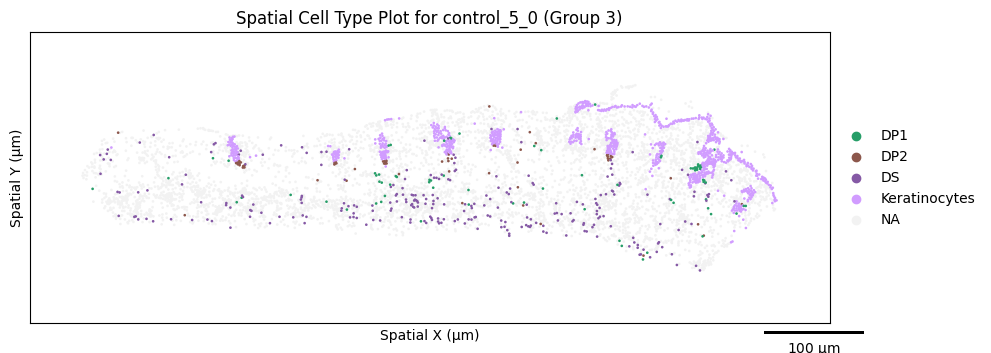

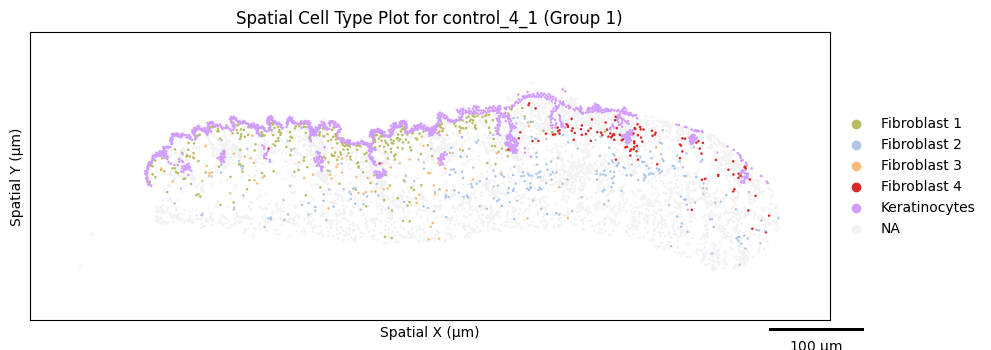

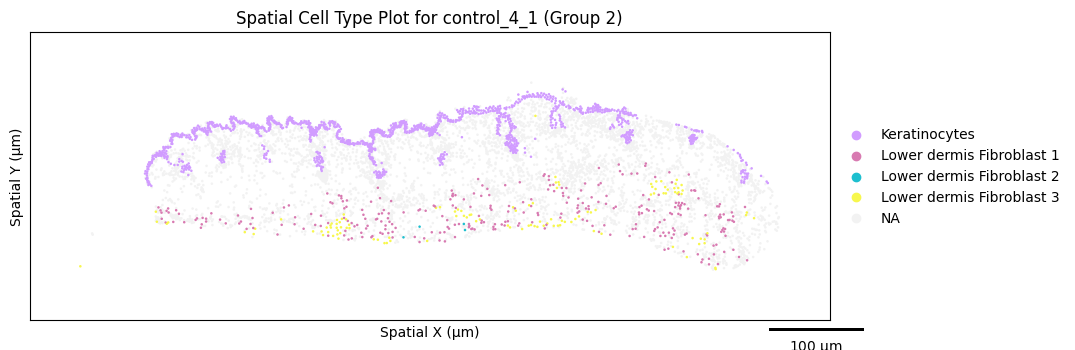

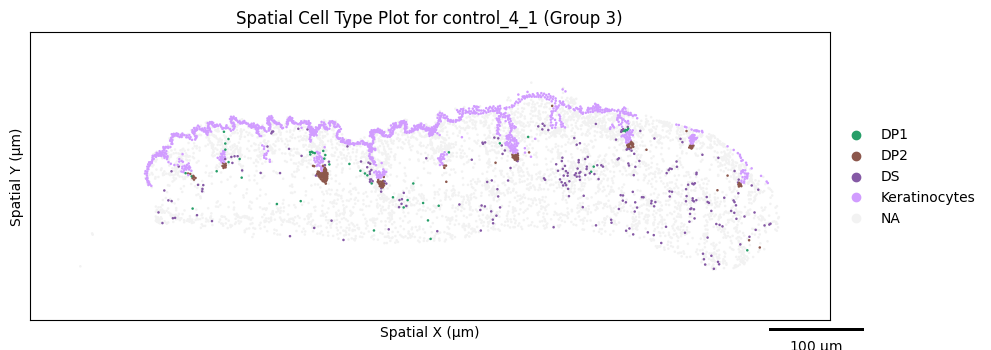

In [49]:
# Define groups to exclude in the 4th plot
groups_to_exclude = set().union(*group_sets)  # Combine all 3 group sets into a single set
groups_to_exclude.discard("Keratinocytes")  # Keep "Keratinocytes" in the 4th plot

# Main loop for processing each sample
for sample_name, sample_parameters in sample_params.items():
    rotation_angle = sample_parameters['angle']
    spot_diameter = sample_parameters['spot_size']
    
    # Subset and process the sample
    sample_spatial_coordinates = st_data[st_data.obs['sample'] == sample_name].obsm['spatial'].copy()
    sample_midpoints = np.mean(sample_spatial_coordinates, axis=0)  # Get mean for x and y separately
    
    # Rotate spatial coordinates
    rotated_coordinates = np.array([
        rotate_point(coordinate, sample_midpoints, rotation_angle) for coordinate in sample_spatial_coordinates
    ])
    
    # Create a temporary AnnData object with rotated spatial coordinates
    sample_adata_rotated = st_data[st_data.obs['sample'] == sample_name].copy()
    sample_adata_rotated.obsm['spatial'] = rotated_coordinates
    
    # Filter cells by `popv_majority_vote_score` greater than 3
    cells_to_plot = sample_adata_rotated.obs['popv_majority_vote_score'] > 2
    # cells_to_plot = sample_adata_rotated.obs['popv_scanvi_prediction_probabilities']>0.9
    filtered_sample_adata = sample_adata_rotated[cells_to_plot].copy()

    # Calculate axis limits based on filtered sample data
    x_min, x_max = filtered_sample_adata.obsm['spatial'][:, 0].min(), filtered_sample_adata.obsm['spatial'][:, 0].max()
    y_min, y_max = filtered_sample_adata.obsm['spatial'][:, 1].min(), filtered_sample_adata.obsm['spatial'][:, 1].max()

    # Loop over each group set
    for group_index, group_set in enumerate(group_sets):
        # Plot the spatial image and overlay cell types
        figure, axis = plt.subplots(figsize=(10, 8))
        figure.patch.set_facecolor('white')
        axis.set_facecolor('white')

        # Plot the spatial image with cell types, only for filtered cells
        sc.pl.spatial(
            filtered_sample_adata,
            spot_size=spot_diameter * 100,
            # color='popv_majority_vote_prediction',
            color='popv_scanvi_prediction',
            palette=celltype_cmap,
            groups=group_set,
            na_color='#F2F2F2',  # Non-selected groups in light gray
            ax=axis,
            show=False
        )
        print()
        # Set fixed axis limits for the specific sample
        axis.set_xlim(x_min -250, x_max +250)
        axis.set_ylim(y_max +250, y_min -250)

        # Add the scale bar to the plot
        add_scale_bar_to_ax(axis, size_of_one_pixel=pixel_size_x, units="µm")

        # Final plot adjustments
        axis.set_title(f'Spatial Cell Type Plot for {sample_name} (Group {group_index + 1})')
        axis.set_xlabel('Spatial X (µm)')
        axis.set_ylabel('Spatial Y (µm)')
        # plt.tight_layout()
        plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Adjust margins as needed
        plt.show()
        # Save the plot as an SVG file
        # plot_filename = f'skin_expansion_xenium/celltype_plot_{sample_name}_group{group_index + 1}.svg'
        # figure.savefig(plot_filename, dpi=200, bbox_inches='tight', transparent=True)
        # plt.close(figure)  # Close the figure after saving

In [ ]:
# Define groups to exclude in the 4th plot
groups_to_exclude = set().union(*group_sets)  # Combine all 3 group sets into a single set
groups_to_exclude.discard("Keratinocytes")  # Keep "Keratinocytes" in the 4th plot

# Main loop for processing each sample
for sample_name, sample_parameters in sample_params.items():
    rotation_angle = sample_parameters['angle']
    spot_diameter = sample_parameters['spot_size']
    
    # Subset and process the sample
    sample_spatial_coordinates = st_data[st_data.obs['sample'] == sample_name].obsm['spatial'].copy()
    sample_midpoints = np.mean(sample_spatial_coordinates, axis=0)  # Get mean for x and y separately
    
    # Rotate spatial coordinates
    rotated_coordinates = np.array([
        rotate_point(coordinate, sample_midpoints, rotation_angle) for coordinate in sample_spatial_coordinates
    ])
    
    # Create a temporary AnnData object with rotated spatial coordinates
    sample_adata_rotated = st_data[st_data.obs['sample'] == sample_name].copy()
    sample_adata_rotated.obsm['spatial'] = rotated_coordinates
    
    # Filter cells by `popv_majority_vote_score` greater than 3
    cells_to_plot = sample_adata_rotated.obs['popv_majority_vote_score'] > 0
    filtered_sample_adata = sample_adata_rotated[cells_to_plot].copy()

    # Calculate axis limits based on filtered sample data
    x_min, x_max = filtered_sample_adata.obsm['spatial'][:, 0].min(), filtered_sample_adata.obsm['spatial'][:, 0].max()
    y_min, y_max = filtered_sample_adata.obsm['spatial'][:, 1].min(), filtered_sample_adata.obsm['spatial'][:, 1].max()
    
    figure, axis = plt.subplots(figsize=(10, 8))
    figure.patch.set_facecolor('white')
    axis.set_facecolor('white')

    # Plot the spatial image with cell types, only for filtered cells
    sc.pl.spatial(
        filtered_sample_adata,
        spot_size=spot_diameter * 100,
        color='popv_majority_vote_score',
        # palette=celltype_cmap,
        # groups=group_set,
        na_color='#F2F2F2',  # Non-selected groups in light gray
        ax=axis,
        show=False
    )
    # Set fixed axis limits for the specific sample
    axis.set_xlim(x_min -250, x_max +250)
    axis.set_ylim(y_max +250, y_min -250)

    # Add the scale bar to the plot
    add_scale_bar_to_ax(axis, size_of_one_pixel=pixel_size_x, units="µm")

    # Final plot adjustments
    axis.set_title(f'Spatial Prediction Score Plot for {sample_name}')
    axis.set_xlabel('Spatial X (µm)')
    axis.set_ylabel('Spatial Y (µm)')
    # plt.tight_layout()
    plt.subplots_adjust(left=0.1, right=1.5, top=0.9, bottom=0.1)  # Adjust margins as needed
    # plt.show()
    # Save the plot as an SVG file
    plot_filename = f'skin_expansion_xenium/prediction_score_{sample_name}.svg'
    figure.savefig(plot_filename, dpi=200, bbox_inches='tight', transparent=True)
    plt.close(figure)  # Close the figure after saving

In [21]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# Genes to analyze
genes = [
'Lrp1'
]

# Sample-specific parameters
sample_params = {
    # 'control_1_0': {'angle': -110, 'spot_size': 0.15},
    'control_2_0': {'angle': -110, 'spot_size': 0.15},
    'control_2_1': {'angle': -100, 'spot_size': 0.1},
    # 'control_4_0': {'angle': 0, 'spot_size': 0.125},
    'control_5_0': {'angle': 180, 'spot_size': 0.125},
    'control_4_1': {'angle': -10, 'spot_size': 0.125},
    # 'control_5_1': {'angle': -185, 'spot_size': 0.125},
}

# Scaling parameters
pixel_size_x = 0.2125  # Microns per pixel for x-axis

# Function to rotate spatial points
def rotate_point(point, origin, angle):
    """Rotate a point counterclockwise by a given angle around a given origin."""
    angle_rad = np.radians(angle)
    ox, oy = origin
    px, py = point
    qx = ox + np.cos(angle_rad) * (px - ox) - np.sin(angle_rad) * (py - oy)
    qy = oy + np.sin(angle_rad) * (px - ox) + np.cos(angle_rad) * (py - oy)
    return qx, qy

# Main loop for processing each sample
for sample_name, sample_parameters in sample_params.items():
    rotation_angle = sample_parameters['angle']
    spot_diameter = sample_parameters['spot_size']

    # Subset and process the sample
    spatial_coordinates = st_data[st_data.obs['sample'] == sample_name].obsm['spatial'].copy()
    spatial_midpoints = np.mean(spatial_coordinates, axis=0)

    # Rotate spatial coordinates
    rotated_coordinates = np.array([rotate_point(coord, spatial_midpoints, rotation_angle) for coord in spatial_coordinates])

    # Create a temporary AnnData object with rotated spatial coordinates
    sample_adata_rotated = st_data[st_data.obs['sample'] == sample_name].copy()
    sample_adata_rotated.obsm['spatial'] = rotated_coordinates

    # Bin size for the grid
    bin_size = 20  # Adjust as needed

    # Create a grid for the spatial data
    x_bins = np.arange(spatial_coordinates[:, 0].min(), spatial_coordinates[:, 0].max(), bin_size)
    y_bins = np.arange(spatial_coordinates[:, 1].min(), spatial_coordinates[:, 1].max(), bin_size)

    # Loop over each gene to create and save the plot
    for gene in genes:
        # Get the gene expression
        expression = sample_adata_rotated[:, gene].layers['rawcounts'].A.flatten()

        # Bin the spatial coordinates and compute mean expression in each bin
        digitized_x = np.digitize(spatial_coordinates[:, 0], bins=x_bins) - 1
        digitized_y = np.digitize(spatial_coordinates[:, 1], bins=y_bins) - 1

        heatmap = np.zeros((len(x_bins) - 1, len(y_bins) - 1))
        for i in range(len(x_bins) - 1):
            for j in range(len(y_bins) - 1):
                in_bin = (digitized_x == i) & (digitized_y == j)
                if in_bin.sum() > 0:
                    heatmap[i, j] = expression[in_bin].mean()

        # Plot the spatial image and overlay the heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')

        # Plot the spatial image using Scanpy
        sc.pl.spatial(
            sample_adata_rotated,
            spot_size=spot_diameter * 100,
            color=None,
            na_color='#F2F2F2',
            ax=ax,
            show=False
        )

        # Normalize the heatmap
        vmin = 0
        vmax = expression.mean() + 2 * expression.std()
        heatmap_clipped = np.clip(heatmap, vmin, vmax)
        scaled_heatmap = MinMaxScaler(feature_range=(0, 1)).fit_transform(heatmap_clipped.flatten().reshape(-1, 1)).reshape(heatmap.shape)

        # Plot the heatmap
        ax.imshow(
            scaled_heatmap.T,
            origin='lower',
            extent=(x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]),
            cmap='viridis',
            alpha=1
        )

        # Add the scale bar
        add_scale_bar_to_ax(ax, size_of_one_pixel=pixel_size_x, units="µm")

        # Add colorbar
        plt.colorbar(ax.images[-1], ax=ax, label=f'Expression of {gene}')

        # Final adjustments
        ax.set_title(f'Spatial Density Plot for {gene} in {sample_name} (bin size {bin_size})')
        ax.set_xlabel('Spatial X (µm)')
        ax.set_ylabel('Spatial Y (µm)')
        plt.tight_layout()

        # Save the plot
        plot_filename = f'skin_expansion_xenium/density_plot_{gene}_{sample_name}_bin{bin_size}.svg'
        fig.savefig(plot_filename, dpi=200, bbox_inches='tight', transparent=True)
        plt.close(fig)

ValueError: negative dimensions are not allowed

In [28]:
scrna_data

View of AnnData object with n_obs × n_vars = 22184 × 474
    obs: 'scdbl_class', 'batch', 'condition', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'leiden_res_1.0', 'leiden_res_0.5', 'leiden_res_0.2', 'celltype', 'hash.ID', 'celltype_caro', 'celltype_deep'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'batch_colors', 'condition_colors', 'dea_leiden_0.2', 'dendrogram_leiden_res_0.2', 'hash.ID_colors', 'hvg', 'leiden', 'leiden_res_0.2_colors', 'leiden_res_0.5_colors', 'leiden_res_1.0_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm:

In [29]:
st_data.obs['popv_majority_vote_prediction']

KeyError: 'popv_majority_vote_prediction'

In [ ]:
sc.pl.heatmap(filtered_scrna_data,var_names=unique_marker_genes,groupby='celltype_deep',layer='logcounts',standard_scale='var')

In [210]:
st_data.X = st_data.layers['log1p_norm']
scrna_data.X = scrna_data.layers['logcounts']

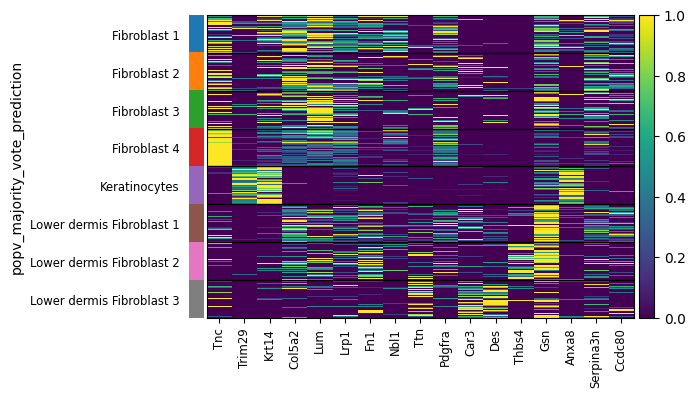

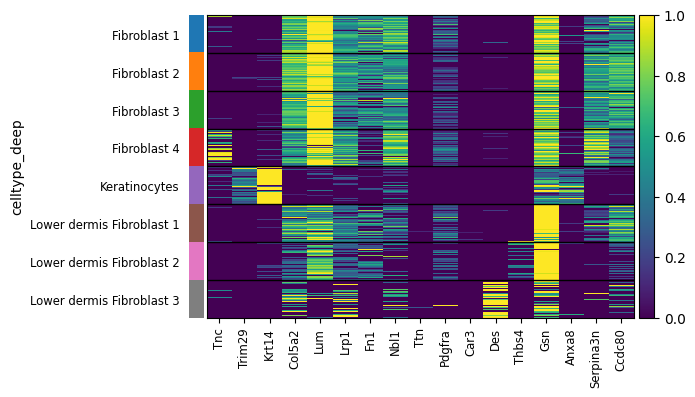

In [230]:
import scanpy as sc
import pandas as pd

# Set the number of cells to sample per cell type
n_cells = 50

# Subsample `filtered_st_data` to have a maximum of `n_cells` per cell type
sampled_indices_st_data = (
    filtered_st_data.obs.groupby('popv_majority_vote_prediction')
    .apply(lambda x: x.sample(n=min(len(x), n_cells), random_state=42).index)
    .explode()  # Flatten the multi-index series into a regular series
)
sampled_filtered_st_data = filtered_st_data[sampled_indices_st_data]

# Subsample `filtered_scrna_data` to have a maximum of `n_cells` per cell type
sampled_indices_scrna_data = (
    filtered_scrna_data.obs.groupby('celltype_deep')
    .apply(lambda x: x.sample(n=min(len(x), n_cells), random_state=42).index)
    .explode()  # Flatten the multi-index series into a regular series
)
sampled_filtered_scrna_data = filtered_scrna_data[sampled_indices_scrna_data]

# Plot the heatmap for the subsampled spatial data (`sampled_filtered_st_data`)
sc.pl.heatmap(
    sampled_filtered_st_data,
    var_names=unique_marker_genes,
    groupby='popv_majority_vote_prediction',
    layer='log1p_norm',
    standard_scale='obs',
    figsize=(6, 4)
)

# Plot the heatmap for the subsampled scRNA-seq data (`sampled_filtered_scrna_data`)
sc.pl.heatmap(
    sampled_filtered_scrna_data,
    var_names=unique_marker_genes,
    groupby='celltype_deep',
    layer='logcounts',
    standard_scale='obs',
    figsize=(6, 4)
)


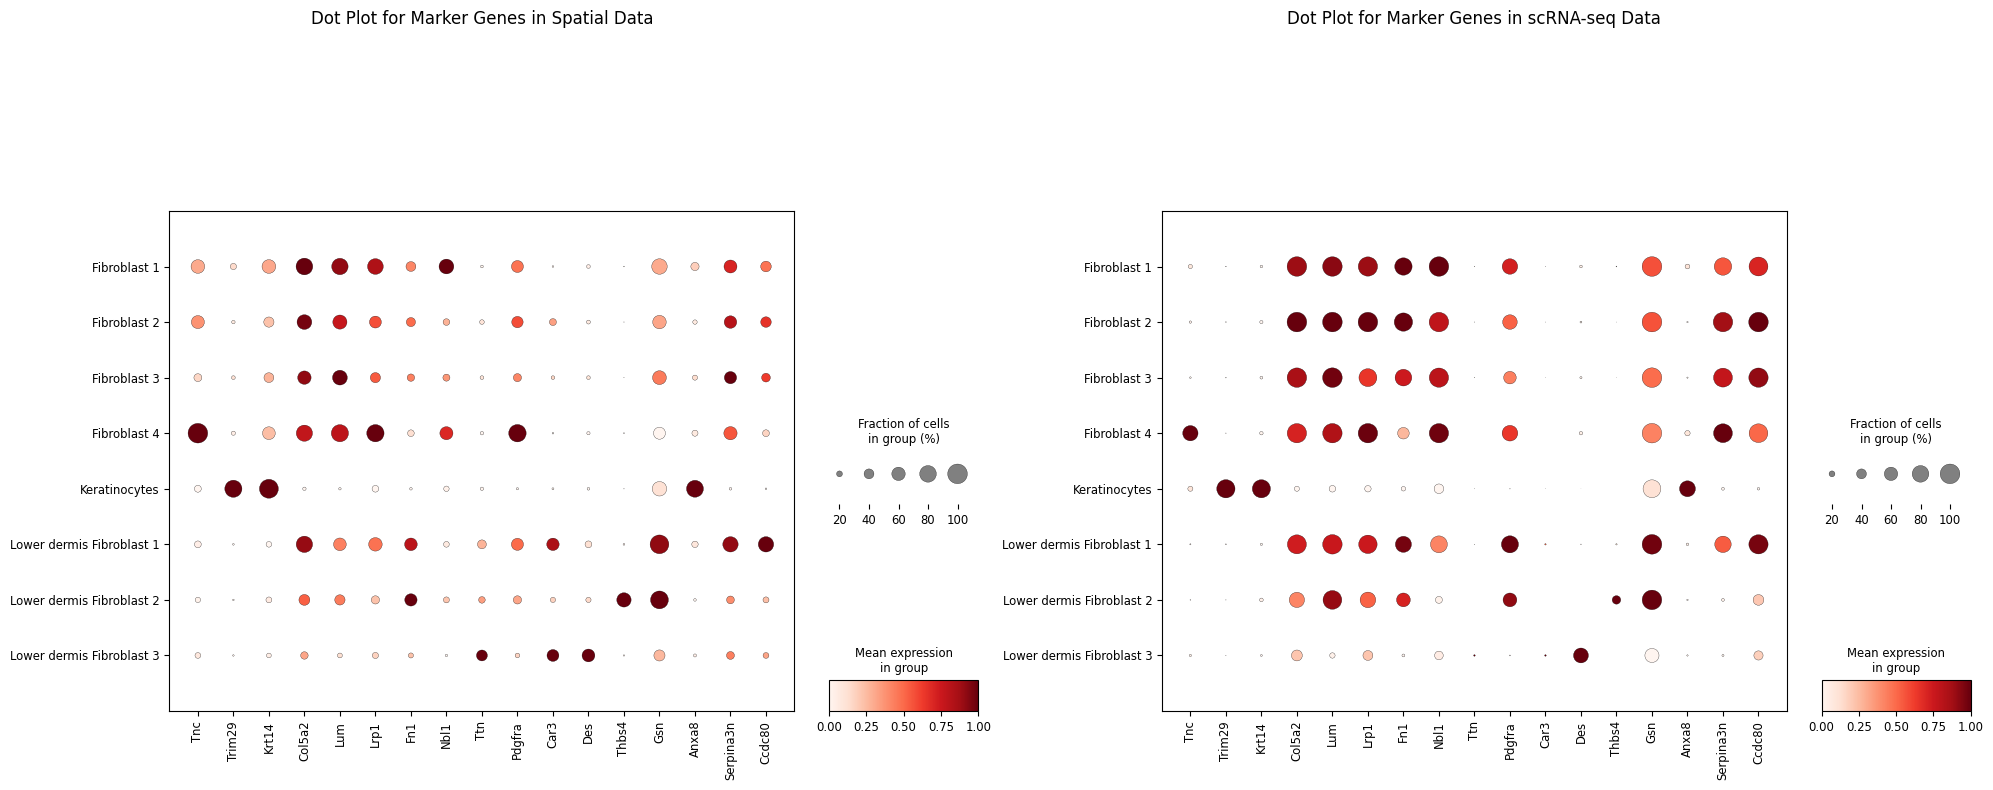

In [211]:
import matplotlib.pyplot as plt
import scanpy as sc

# Create a figure with subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('white')

# Filter the spatial data (`st_data`) to include only the desired cell types
filtered_st_data = st_data[st_data.obs['popv_majority_vote_prediction'].isin(desired_cell_type_order)].copy()

# Plot the dotplot for the filtered spatial data (`filtered_st_data`) on the first axis
sc.pl.dotplot(
    filtered_st_data,
    var_names=unique_marker_genes,
    groupby='popv_majority_vote_prediction',  # Use the cell type annotations in `st_data`
    standard_scale='var',  # Scale across variables (genes)
    title="Dot Plot for Marker Genes in Spatial Data",
    dendrogram=False,
    ax=axes[0],  # Use the first axis
    show=False
)

# Filter the scRNA-seq data (`scrna_data`) to include only the desired cell types
filtered_scrna_data = scrna_data[scrna_data.obs['celltype_deep'].isin(desired_cell_type_order)].copy()

# Plot the dotplot for the filtered scRNA-seq data (`filtered_scrna_data`) on the second axis
sc.pl.dotplot(
    filtered_scrna_data,
    var_names=unique_marker_genes,
    groupby='celltype_deep',  # Use the cell type annotations in `scrna_data`
    standard_scale='var',  # Scale across variables (genes)
    title="Dot Plot for Marker Genes in scRNA-seq Data",
    dendrogram=False,
    ax=axes[1],  # Use the second axis
    show=False
)

# Adjust the layout
plt.tight_layout()

# Show the combined figure with both dotplots
plt.show()


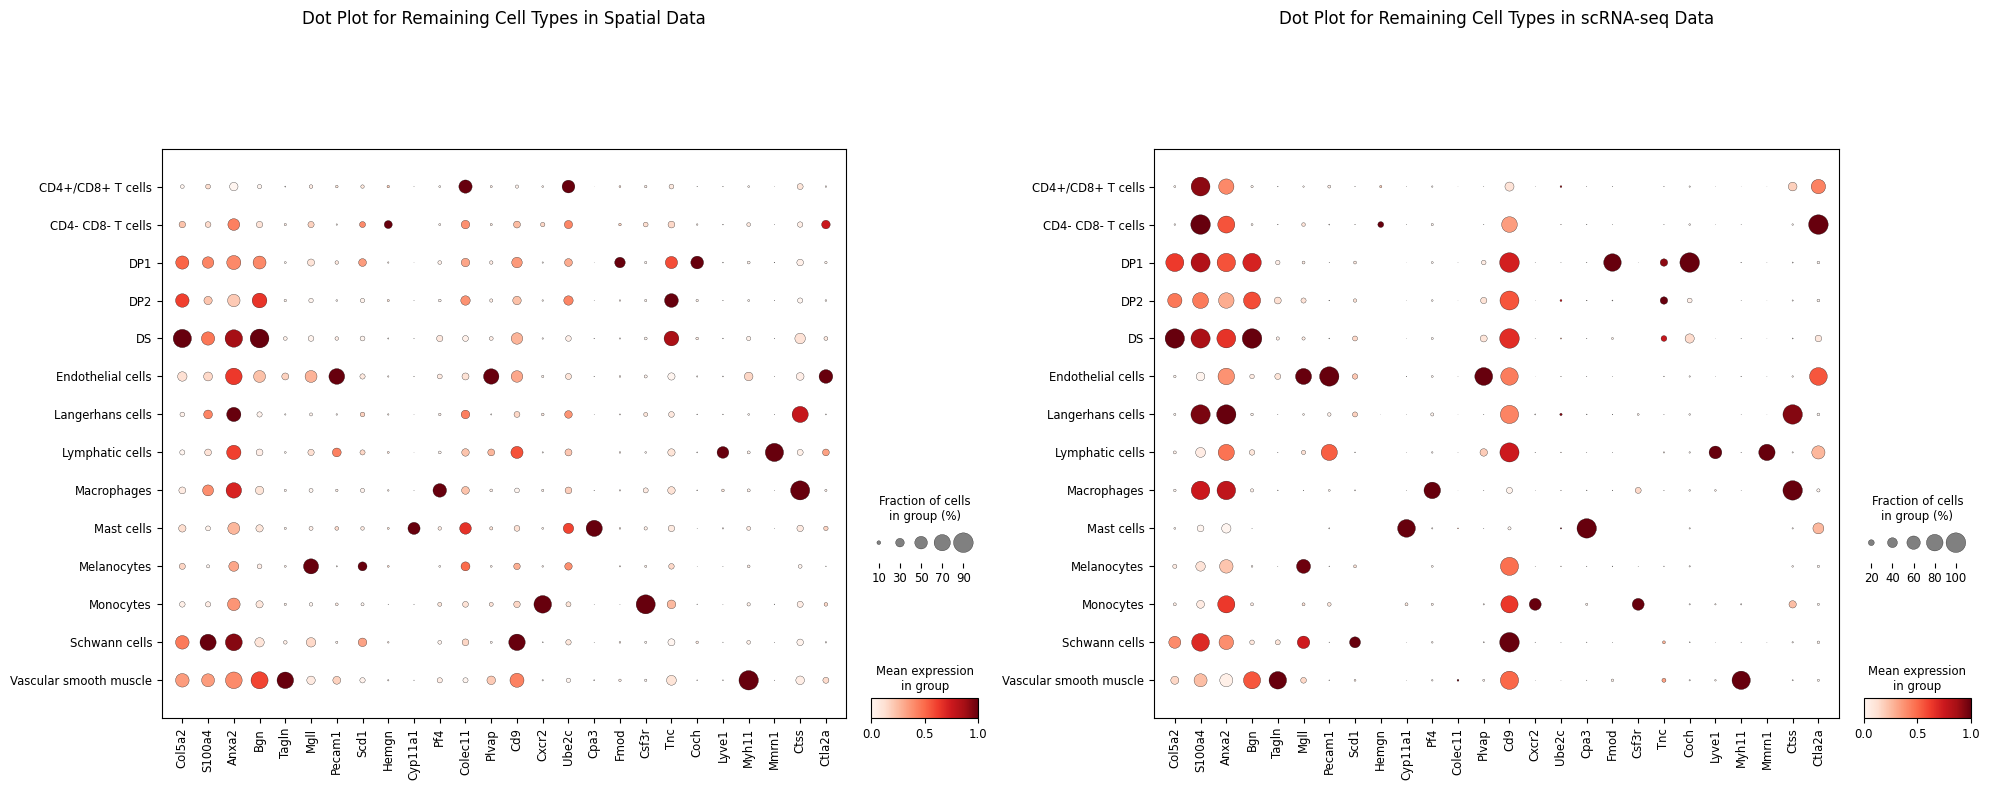

In [212]:
import matplotlib.pyplot as plt
import scanpy as sc

# List of cell types to exclude
excluded_cell_types = [
    'Keratinocytes', 'Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4',
    'Lower dermis Fibroblast 1', 'Lower dermis Fibroblast 2', 'Lower dermis Fibroblast 3'
]

# Filter the spatial data (`st_data`) to exclude the specified cell types
remaining_cell_types_st_data = st_data[~st_data.obs['popv_majority_vote_prediction'].isin(excluded_cell_types)].copy()

# Perform differential expression analysis on the filtered data
sc.tl.rank_genes_groups(
    remaining_cell_types_st_data,
    groupby='popv_majority_vote_prediction',  # Column with cell type annotations
    method='t-test',  # Method for differential expression analysis
    reference='rest'  # Compare each group to the rest
)

# Retrieve the top marker genes for each cell type in the filtered data
remaining_top_marker_genes = {}
for cell_type in remaining_cell_types_st_data.obs['popv_majority_vote_prediction'].unique():
    if cell_type in remaining_cell_types_st_data.uns['rank_genes_groups']['names'].dtype.names:
        top_genes = remaining_cell_types_st_data.uns['rank_genes_groups']['names'][cell_type][:2]  # Select top 2 markers
        remaining_top_marker_genes[cell_type] = top_genes

# Extract unique marker genes
unique_marker_genes_remaining = list(set([gene for genes in remaining_top_marker_genes.values() for gene in genes]))

# Filter the scRNA-seq data (`scrna_data`) to exclude the specified cell types
filtered_scrna_data_remaining = scrna_data[~scrna_data.obs['celltype_deep'].isin(excluded_cell_types)].copy()

# Create a figure with subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('white')

# Plot the dotplot for the remaining cell types in spatial data (`remaining_cell_types_st_data`)
sc.pl.dotplot(
    remaining_cell_types_st_data,
    var_names=unique_marker_genes_remaining,
    groupby='popv_majority_vote_prediction',  # Use the cell type annotations in `st_data`
    standard_scale='var',  # Scale across variables (genes)
    title="Dot Plot for Remaining Cell Types in Spatial Data",
    dendrogram=False,
    ax=axes[0],  # Use the first axis
    show=False
)

# Plot the dotplot for the remaining cell types in scRNA-seq data (`filtered_scrna_data_remaining`)
sc.pl.dotplot(
    filtered_scrna_data_remaining,
    var_names=unique_marker_genes_remaining,
    groupby='celltype_deep',  # Use the cell type annotations in `scrna_data`
    standard_scale='var',  # Scale across variables (genes)
    title="Dot Plot for Remaining Cell Types in scRNA-seq Data",
    dendrogram=False,
    ax=axes[1],  # Use the second axis
    show=False
)

# Adjust the layout
plt.tight_layout()

# Show the combined figure with both dotplots
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, wilcoxon

def analyze_cluster_proportions(full_adata, subset_adata, cluster_key, slide_key, output_dir):
    """
    Analyze cluster proportions between full dataset and subset, perform statistical tests, and visualize results.

    Parameters
    ----------
    full_adata : AnnData
        The full dataset containing all cells.
    subset_adata : AnnData
        The subset of cells of interest.
    cluster_key : str
        Column in `.obs` representing cluster annotations.
    slide_key : str
        Column in `.obs` representing slide or region information.
    output_dir : str
        Directory to save plots and results.

    Returns
    -------
    proportions_df : pd.DataFrame
        DataFrame containing proportions and differences for all clusters.
    significance_df : pd.DataFrame
        DataFrame containing Wilcoxon test results for each cluster.
    """

    # Get common indices
    common_indices = full_adata.obs.index.intersection(subset_adata.obs.index)

    # Subset full_adata to match subset cells for accurate proportion comparisons
    subset_common = full_adata[c


In [14]:
processed_adata = sc.read_h5ad('skin_expansion_data/query_and_reference_popv.h5ad')
epidermis = sc.read_h5ad('skin_expansion_data/annotated_epidermis.h5ad')

In [15]:
spatial_data_all = processed_adata[processed_adata.obs['_dataset']=='query']
spatial_data_all = spatial_data_all[spatial_data_all.obs['popv_majority_vote_score']>2]
spatial_data_all.obs['annotation'] =list(spatial_data_all.obs['popv_majority_vote_prediction'])
spatial_data_all = spatial_data_all[spatial_data_all.obs['sample'].isin(('control_1_0','control_4_1','control_5_0'))]
# spatial_data_all = spatial_data_all[spatial_data_all.obs['sample'].isin(('control_2_1',))]

matching_indices = spatial_data_all.obs.index.intersection(epidermis.obs.index)
spatial_data_all.obs['epidermis'] = False
spatial_data_all.obs.loc[matching_indices, 'epidermis'] = True
# Define the regions of interest
x_min, x_max = 1100, 2500
y_min, y_max = 2600, 3500
spatial_data_all = spatial_data_all[
    (spatial_data_all.obs['sample'] != 'control_5_0') |  # Keep all other samples
    (  # Apply region filtering only to 'control_5_0'
        (spatial_data_all.obs['sample'] == 'control_5_0') &
        (spatial_data_all.obs['x_centroid'] >= x_min) &
        (spatial_data_all.obs['x_centroid'] <= x_max) &
        (spatial_data_all.obs['y_centroid'] >= y_min) &
        (spatial_data_all.obs['y_centroid'] <= y_max)
    )
].copy()

/tmp/ipykernel_1890794/3745064979.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  spatial_data_all.obs['annotation'] =list(spatial_data_all.obs['popv_majority_vote_prediction'])
/tmp/ipykernel_1890794/3745064979.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  spatial_data_all.obs['epidermis'] = False


In [7]:
def calculate_distances_to_epidermis_per_sample_um(spatial_data, annotation_column='annotation', sample_column='sample', pixel_to_micron=0.2125, output_path=None):
    """
    Calculate the minimum distance of each cell to the closest cell in the subset (epidermis) in microns and plot a boxplot.

    Parameters
    ----------
    spatial_data : AnnData
        AnnData object containing spatial data and the 'epidermis' column (with 1s and 0s).
    annotation_column : str
        Column in .obs to group distances by cell types.
    sample_column : str
        Column in .obs specifying the sample each cell belongs to.
    pixel_to_micron : float
        Conversion factor to convert pixel distances to microns.
    output_path : str, optional
        Path to save the resulting boxplots and CSV. If None, the plots are shown instead.

    Returns
    -------
    distances_df : pd.DataFrame
        DataFrame containing distances for each cell (in microns), grouped by cell type and sample.
    """
    # Initialize a list to store distances for each sample
    distances_data = []

    # Iterate over each sample in the dataset
    for sample in spatial_data.obs[sample_column].unique():
        # Subset the data for the current sample
        sample_data = spatial_data[spatial_data.obs[sample_column] == sample]
        
        # Extract spatial coordinates for all cells in the sample
        all_coords = sample_data.obsm['spatial']

        # Extract spatial coordinates for cells marked as epidermis in the sample
        epidermis_coords = all_coords[sample_data.obs['epidermis'] == True]
        
        if epidermis_coords.shape[0] == 0:
            print(f"No cells marked as 'epidermis=1' in sample {sample}. Skipping...")
            continue
        
        # Calculate pairwise distances (Euclidean)
        distances = cdist(all_coords, epidermis_coords)
        
        # Find the minimum distance to any cell in the epidermis for each cell
        min_distances = distances.min(axis=1)
        
        # Create a DataFrame with distances, cell types, and sample
        distances_sample_df = pd.DataFrame({
            'Sample': sample,
            'Cell Type': sample_data.obs[annotation_column].values,
            'Distance (µm)': min_distances
        })
        
        # Append to the list
        distances_data.append(distances_sample_df)
    
    # Combine all sample-specific DataFrames
    distances_df = pd.concat(distances_data, ignore_index=True)
    
    # Order cell types if a specific order is desired
    desired_order = ['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4',
                     'Lower dermis Fibroblast 1', 'Lower dermis Fibroblast 2', 'Lower dermis Fibroblast 3']
    distances_df['Cell Type'] = pd.Categorical(distances_df['Cell Type'], categories=desired_order, ordered=True)

    # Save CSV with raw data
    if output_path:
        csv_filename = f"{output_path}/all_min_distance_to_epidermis_per_sample_um.csv"
        distances_df.to_csv(csv_filename, index=False)
        print(f"Raw data saved to {csv_filename}")

    # Create a boxplot grouped by cell types and samples
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=distances_df,
        x='Cell Type',
        y='Distance (µm)',
        hue='Sample',
        palette='Set2',
        showfliers=False
    )
    plt.xticks(rotation=90)
    plt.title('Distance of Cells to Nearest Epidermis Cell per Sample (in Microns)')
    plt.ylabel('Distance (µm)')
    plt.xlabel('Cell Type')
    plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save or show the plot
    if output_path:
        plot_filename = f"{output_path}/all_min_distance_to_epidermis_per_sample_boxplot_um.svg"
        plt.savefig(plot_filename, dpi=200, bbox_inches="tight", transparent=True)
        plt.close()
        print(f"Plot saved to {plot_filename}")
    else:
        plt.show()

    return distances_df

In [343]:
def calculate_distances_to_epidermis_per_sample_um_group(
    spatial_data, annotation_column='annotation', sample_column='sample', pixel_to_micron=0.2125, output_path=None
):
    """
    Calculate the minimum distance of each cell to the closest cell in the subset (epidermis) in microns and plot a boxplot.

    Parameters
    ----------
    spatial_data : AnnData
        AnnData object containing spatial data and the 'epidermis' column (with 1s and 0s).
    annotation_column : str
        Column in `.obs` to group distances by cell types.
    sample_column : str
        Column in `.obs` specifying the sample each cell belongs to.
    pixel_to_micron : float
        Conversion factor to convert pixel distances to microns.
    output_path : str, optional
        Path to save the resulting boxplots. If None, the plots are shown instead.

    Returns
    -------
    distances_df : pd.DataFrame
        DataFrame containing distances for each cell (in microns), grouped by cell type and sample.
    """
    # Initialize a list to store distances for each sample
    distances_data = []

    # Iterate over each sample in the dataset
    for sample in spatial_data.obs[sample_column].unique():
        # Subset the data for the current sample
        sample_data = spatial_data[spatial_data.obs[sample_column] == sample]
        
        # Extract spatial coordinates for all cells in the sample
        # all_coords = sample_data.obsm['spatial'] * pixel_to_micron  # Convert to microns
        all_coords= sample_data.obsm['spatial']
        # Extract spatial coordinates for cells marked as epidermis in the sample
        epidermis_coords = all_coords[sample_data.obs['epidermis'] == True]
        
        if epidermis_coords.shape[0] == 0:
            print(f"No cells marked as 'epidermis=1' in sample {sample}. Skipping...")
            continue
        
        # Calculate pairwise distances (Euclidean)
        distances = cdist(all_coords, epidermis_coords)
        
        # Find the minimum distance to any cell in the epidermis for each cell
        min_distances = distances.min(axis=1)
        
        # Create a DataFrame with distances, cell types, and sample
        distances_sample_df = pd.DataFrame({
            'Sample': sample,
            'Cell Type': sample_data.obs[annotation_column].values,
            'Distance (µm)': min_distances  # Already in microns
        })
        
        # Append to the list
        distances_data.append(distances_sample_df)
    
    # Combine all sample-specific DataFrames
    distances_df = pd.concat(distances_data, ignore_index=True)

    # Order cell types if a specific order is desired
    desired_order = ['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4',
                     'Lower dermis Fibroblast 1', 'Lower dermis Fibroblast 2', 'Lower dermis Fibroblast 3']
    distances_df['Cell Type'] = pd.Categorical(distances_df['Cell Type'], categories=desired_order, ordered=True)

    # Create a boxplot with samples on the x-axis and colored by cell type
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=distances_df,
        x='Sample',
        y='Distance (µm)',
        hue='Cell Type',
        palette='Set2',
        showfliers=False
    )
    plt.xticks(rotation=90)
    plt.title('Distance of Cells to Nearest Epidermis Cell per Sample (in Microns)')
    plt.ylabel('Distance (µm)')
    plt.xlabel('Sample')
    plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save or show the plot
    if output_path:
        plot_filename = f"{output_path}/all_min_distance_to_epidermis_samples_boxplot_grouped_um.svg"
        plt.savefig(plot_filename, dpi=200, bbox_inches="tight", transparent=True)
        plt.close()
        print(f"Plot saved to {plot_filename}")
    else:
        plt.show()

    return distances_df


In [12]:
from scipy.spatial.distance import cdist
import pandas as pd
# Example usage:
distances_df_um = calculate_distances_to_epidermis_per_sample_um(
    spatial_data=spatial_data_all,
    annotation_column='annotation',
    sample_column='sample',
    pixel_to_micron=0.2125,
    output_path="skin_expansion_xenium/distance_results/"
)

Raw data saved to skin_expansion_xenium/distance_results//all_min_distance_to_epidermis_per_sample_um.csv
Plot saved to skin_expansion_xenium/distance_results//all_min_distance_to_epidermis_per_sample_boxplot_um.svg


In [344]:

# Example usage:
distances_df_um = calculate_distances_to_epidermis_per_sample_um(
    spatial_data=spatial_data_all,
    annotation_column='annotation',
    sample_column='sample',
    pixel_to_micron=0.2125,
    output_path="skin_expansion_xenium/distance_results/"
)

# Example usage:
distances_df_um = calculate_distances_to_epidermis_per_sample_um_group(
    spatial_data=spatial_data_all,
    annotation_column='annotation',
    sample_column='sample',
    pixel_to_micron=0.2125,
    output_path="skin_expansion_xenium/distance_results/"
)

Plot saved to skin_expansion_xenium/distance_results//all_min_distance_to_epidermis_per_sample_boxplot_um.svg
Plot saved to skin_expansion_xenium/distance_results//all_min_distance_to_epidermis_samples_boxplot_grouped_um.svg


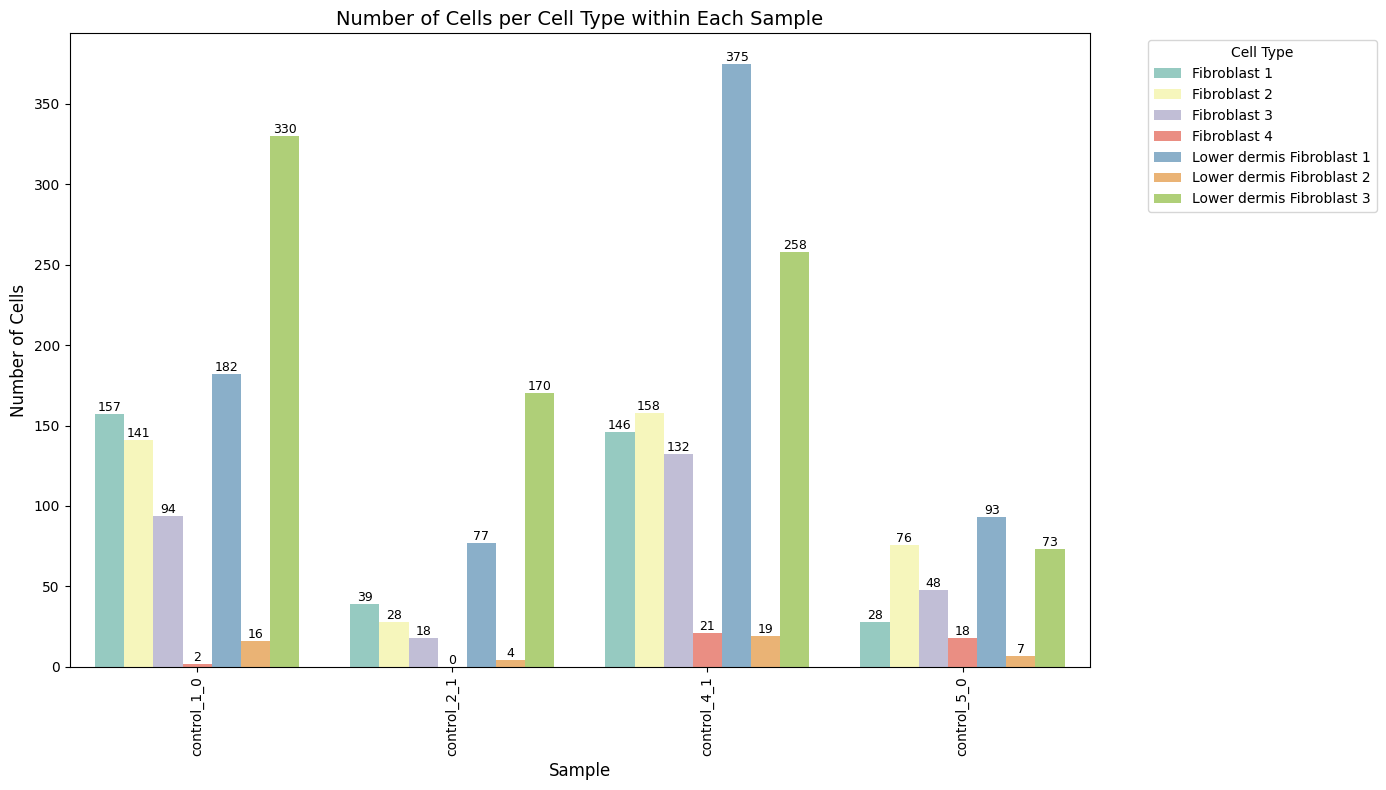

In [291]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Desired order for cell types
desired_order = ['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4',
                 'Lower dermis Fibroblast 1', 'Lower dermis Fibroblast 2', 'Lower dermis Fibroblast 3']

# Group by 'sample' and 'annotation' to count the number of cells
cell_counts_per_sample = (
    spatial_data_all.obs.groupby(['sample', 'annotation'])
    .size()
    .reset_index(name='Number of Cells')
)

# Ensure 'annotation' column follows the desired order
cell_counts_per_sample['annotation'] = pd.Categorical(
    cell_counts_per_sample['annotation'],
    categories=desired_order,
    ordered=True)

# Sort by the categorical order
cell_counts_per_sample = cell_counts_per_sample.sort_values(['sample', 'annotation'])

# Plot the grouped bar plot
plt.figure(figsize=(14, 8))
barplot = sns.barplot(
    data=cell_counts_per_sample,
    x='sample',
    y='Number of Cells',
    hue='annotation',
    palette='Set3'
)

# Annotate the bars with the number of cells
for container in barplot.containers:
    # Add annotations to each bar in the container
    barplot.bar_label(container, label_type='edge', fmt='%d', fontsize=9)

# Add plot labels and title
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.title('Number of Cells per Cell Type within Each Sample', fontsize=14)
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()

# Show the plot
plt.show()

In [101]:
distances_df['Distance_to_Subset'] = distances_df['Distance']*pixel_to_micron


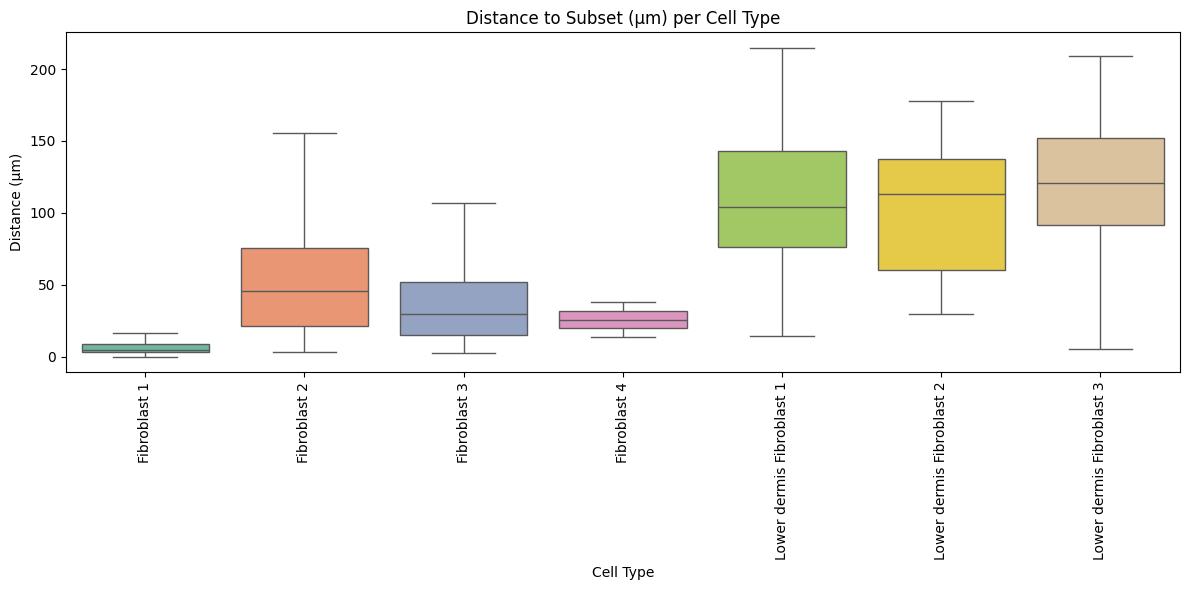

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Define pixel-to-micron scaling factor
pixel_to_micron = 0.2125

# Build a k-d tree for the subset's spatial coordinates
subset_tree = cKDTree(subset_adata.obsm['spatial'])

# Calculate distances to the nearest neighbor in `subset_adata` for all cells in `spatial_data`
distances, _ = subset_tree.query(subset_spatial.obsm['spatial'])

# Convert distances from pixels to microns
distances_in_microns = distances * pixel_to_micron

# Add distances as a new column in `spatial_data.obs`
subset_spatial.obs['Distance_to_Subset'] = distances_in_microns

# Create a boxplot for distance per cell type
distance_df = pd.DataFrame({
    'Distance': subset_spatial.obs['Distance_to_Subset'],
    'Cell_Type': subset_spatial.obs['popv_majority_vote_prediction']  # Adjust the column name to your cell type annotation
}).dropna()  # Drop cells without valid distances or annotations

plt.figure(figsize=(12, 6))
sns.boxplot(data=distance_df, x='Cell_Type', y='Distance', palette="Set2", showfliers=False)
# sns.stripplot(data=distance_df, x='Cell_Type', y='Distance', color='black', alpha=0.5, jitter=True)

# Add labels and title
plt.title('Distance to Subset (µm) per Cell Type')
plt.ylabel('Distance (µm)')
plt.xlabel('Cell Type')
plt.xticks(rotation=90)
plt.tight_layout()

# Save or display the plot
# plt.savefig("distance_to_subset_per_cell_type.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()


In [19]:
import pandas as pd

# ---- Load ----
df = pd.read_csv("skin_expansion_xenium/distance_results/all_min_distance_to_epidermis_per_sample_um.csv")

# ---- Drop unannotated cells (NaN cell type) ----
df = df.dropna(subset=['Cell Type'])

# ---- Rename samples to match figure labels ----
sample_rename = {
    'control_1_0': 'CTRL 1',
    'control_4_1': 'CTRL 2',
    'control_5_0': 'CTRL 3',
}
df['Sample'] = df['Sample'].map(sample_rename)

# ---- Order cell types and samples ----
celltype_order = ['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4',
                  'Lower dermis Fibroblast 1', 'Lower dermis Fibroblast 2', 'Lower dermis Fibroblast 3']
sample_order   = ['CTRL 1', 'CTRL 2', 'CTRL 3']

# ---- Cell counts: cell type × sample ----
counts = (df.groupby(['Cell Type', 'Sample'], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(index=celltype_order, columns=sample_order))

print("=== Cell counts per subtype per sample ===")
print(counts)
print(f"\nTotal per sample:\n{counts.sum(axis=0)}")
print(f"\nTotal per cell type:\n{counts.sum(axis=1)}")

# ---- Build a clean summary table: median, IQR, n, per cell type × sample ----
summary = (df.groupby(['Cell Type', 'Sample'], observed=True)['Distance (µm)']
             .agg(n='count',
                  median='median',
                  Q1=lambda x: x.quantile(0.25),
                  Q3=lambda x: x.quantile(0.75),
                  min='min',
                  max='max')
             .round(1)
             .reset_index())

# Order rows
summary['Cell Type'] = pd.Categorical(summary['Cell Type'], categories=celltype_order, ordered=True)
summary['Sample']    = pd.Categorical(summary['Sample'],    categories=sample_order, ordered=True)
summary = summary.sort_values(['Cell Type', 'Sample']).reset_index(drop=True)

print("\n=== Per-group summary ===")
print(summary.to_string(index=False))

# ---- Save outputs ----
counts.to_csv("skin_expansion_xenium/distance_results/fib_distance_to_epidermis_counts.csv")
summary.to_csv("skin_expansion_xenium/distance_results/fib_distance_to_epidermis_summary.csv", index=False)

# ---- Bonus: wide-format counts in "CTRL1 / CTRL2 / CTRL3" string format ----
# (matches exactly how it appears in the legend)
counts_for_legend = counts.apply(
    lambda row: f"({row['CTRL 1']} / {row['CTRL 2']} / {row['CTRL 3']})", axis=1
)
print("\n=== Legend-ready format ===")
for ct, txt in counts_for_legend.items():
    print(f"  {ct}: {txt}")

=== Cell counts per subtype per sample ===
Sample                     CTRL 1  CTRL 2  CTRL 3
Cell Type                                        
Fibroblast 1                  157     146      28
Fibroblast 2                  141     158      76
Fibroblast 3                   94     132      48
Fibroblast 4                    2      21      18
Lower dermis Fibroblast 1     182     375      93
Lower dermis Fibroblast 2      16      19       7
Lower dermis Fibroblast 3     330     258      73

Total per sample:
Sample
CTRL 1     922
CTRL 2    1109
CTRL 3     343
dtype: int64

Total per cell type:
Cell Type
Fibroblast 1                 331
Fibroblast 2                 375
Fibroblast 3                 274
Fibroblast 4                  41
Lower dermis Fibroblast 1    650
Lower dermis Fibroblast 2     42
Lower dermis Fibroblast 3    661
dtype: int64

=== Per-group summary ===
                Cell Type Sample   n  median    Q1    Q3   min    max
             Fibroblast 1 CTRL 1 157    21.2  13.7

In [21]:
import pandas as pd

# ---- Load ----
df = pd.read_csv("skin_expansion_xenium/distance_results/all_min_distance_to_epidermis_per_sample_um.csv")

# ---- Drop unannotated cells ----
df = df.dropna(subset=['Cell Type'])

# ---- Rename samples to match figure labels ----
sample_rename = {
    'control_1_0': 'CTRL 1',
    'control_4_1': 'CTRL 2',
    'control_5_0': 'CTRL 3',
}
df['Sample'] = df['Sample'].map(sample_rename)

# ---- Order cell types and samples for readability ----
celltype_order = ['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4',
                  'Lower dermis Fibroblast 1', 'Lower dermis Fibroblast 2', 'Lower dermis Fibroblast 3']
sample_order   = ['CTRL 1', 'CTRL 2', 'CTRL 3']

df['Cell Type'] = pd.Categorical(df['Cell Type'], categories=celltype_order, ordered=True)
df['Sample']    = pd.Categorical(df['Sample'],    categories=sample_order, ordered=True)
df = df.sort_values(['Cell Type', 'Sample']).reset_index(drop=True)

# ---- Round distances to 2 decimals for cleaner viewing ----
df['Distance (µm)'] = df['Distance (µm)'].round(2)

# ---- Save ----
out_path = "skin_expansion_xenium/distance_results/fib_distance_to_epidermis_per_cell.csv"
df.to_csv(out_path, index=False)

print(f"Saved {len(df)} rows ({df['Cell Type'].nunique()} cell types × {df['Sample'].nunique()} samples) to:\n{out_path}")
print(f"\nPreview:")
print(df.head(10))

Saved 2374 rows (7 cell types × 3 samples) to:
skin_expansion_xenium/distance_results/fib_distance_to_epidermis_per_cell.csv

Preview:
   Sample     Cell Type  Distance (µm)
0  CTRL 1  Fibroblast 1          13.56
1  CTRL 1  Fibroblast 1          19.24
2  CTRL 1  Fibroblast 1          10.88
3  CTRL 1  Fibroblast 1          10.93
4  CTRL 1  Fibroblast 1          14.41
5  CTRL 1  Fibroblast 1          26.47
6  CTRL 1  Fibroblast 1          10.13
7  CTRL 1  Fibroblast 1          17.36
8  CTRL 1  Fibroblast 1           8.68
9  CTRL 1  Fibroblast 1          58.27


In [69]:
print(spatial_data.obsm['spatial'])

[[1736.58911133 3440.17114258]
 [1756.02905273 3421.46533203]
 [1726.04064941 3440.32958984]
 ...
 [3327.66967773 1851.76037598]
 [3338.04443359 1838.59240723]
 [3568.69897461 1793.62805176]]


In [11]:
spatial_data = processed_adata[processed_adata.obs['_dataset']=='query']

In [3]:
processed_adata = sc.read_h5ad('skin_expansion_data/spatial_data_consensus_celltyping.h5ad')

In [3]:
processed_adata = sc.read_h5ad('skin_expansion_data/query_and_reference_popv.h5ad')

In [ ]:
processed_adata.write(f'skin_expansion_data/query_and_reference_popv.h5ad')